# 03 - EDA, Distribution Shift & Feature Engineering

**Đề tài:** Dự đoán mức lương kỳ vọng dựa trên bản mô tả công việc (Job Description)

**Notebook này bao gồm 3 phần chính:**
1. **EDA (Exploratory Data Analysis)** - Khám phá và mô tả tình trạng dữ liệu sau khi làm sạch
2. **Distribution Shift** - Đánh giá sự khác biệt phân bố giữa tập Train và Test
3. **Feature Engineering** - Trích xuất và mã hóa đặc trưng cho mô hình Machine Learning

---
> **Ghi chú:** Cột biến mục tiêu trong file CSV sạch là `salary_expected_million_vnd` (đơn vị: triệu VNĐ).  
> Notebook này sẽ tự động chuyển đổi thành `salary_avg` (đơn vị: VNĐ) bằng cách nhân với 1,000,000.

## 0. Cài đặt thư viện & Cấu hình

In [320]:
# Cài đặt thư viện cần thiết (chỉ chạy lần đầu nếu chưa cài)
%pip install pandas numpy matplotlib seaborn scikit-learn --quiet

Note: you may need to restart the kernel to use updated packages.


In [321]:
import os
import re
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')
# ============================================================
# CẤU HÌNH CHUNG - Thay đổi SAMPLE_SIZE để chạy nhanh hơn
# Đặt None để chạy toàn bộ dữ liệu (có thể mất nhiều thời gian)
# ============================================================
SAMPLE_SIZE    = None   # Số dòng để load (None = toàn bộ)
RANDOM_STATE   = 42
N_SVD_COMPONENTS = 50    # Số chiều sau khi giảm chiều TF-IDF
N_TSNE_SAMPLE  = 2_000   # Số dòng dùng cho t-SNE (giữ nhỏ để chạy nhanh)
# Đường dẫn đến tập dữ liệu sạch
TRAIN_PATH = r"../artifacts/clean/clean_data_train.csv"
TEST_PATH  = r"../artifacts/clean/clean_data_test.csv"
# Thư mục lưu kết quả Feature Engineering
FEATURES_DIR = r"../artifacts/features"
os.makedirs(FEATURES_DIR, exist_ok=True)
# Cấu hình phong cách đồ thị (Hiện đại, chuyên nghiệp)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.dpi'      : 120,
    'axes.titlesize'  : 14,
    'axes.titleweight': 'bold',
    'axes.labelsize'  : 12,
    'xtick.labelsize' : 10,
    'ytick.labelsize' : 10,
})
# ============================================================
# HÀM CHUẨN HÓA KINH NGHIỆM (Experience Level Standardization)
# ============================================================
def standardize_experience(val):
    if pd.isna(val): 
        return 'không'
    val = str(val).strip().lower()
    if val in ['không', 'không yêu cầu', 'yêu cầu ứng viên có kinh nghiệm', 'chưa có kinh nghiệm', 'unknown', 'khng', 'yu c?u ?ng vin c kinh nghi?m']: 
        return 'không'
    if any(x in val for x in ['dưới 1 năm', '0.5 năm', 'lên đến 1 năm', '0-1', '0 - 1', '0,5', '< 1', 'du?i 1 nam', 'ln d?n 1 nam', '0,5 nam', '0,2 nam']): 
        return 'dưới 1 năm'
    if any(x in val for x in ['1 năm', 'trên 1 năm', '1-2', '1-3', '1 - 2', '1 - 3', '1,5', '1 nam', 'trn 1 nam', '1-2 nam', '1-3 nam', '1,5 - 2 nam', 't? 0 - 2 nam']): 
        return '1 năm'
    if any(x in val for x in ['2 năm', 'trên 2 năm', '2-3', '2-4', '2 - 3', '2 - 4', '2-5', '2 - 5', '2 nam', 'trn 2 nam', '2-3 nam', '2-4 nam', '2-5 nam', '2 - 6 nam', '2 - 8 nam', '2 - 2 nam', 't? 2 - 3 nam']): 
        return '2 năm'
    if any(x in val for x in ['3 năm', 'trên 3 năm', '3-5', '3 - 5', '3-4', '3 - 4', '3 nam', 'trn 3 nam', '3-5 nam', '3-4 nam', 't? 3 nam', 't? 3 - 4 nam', 'ln d?n 3 nam']): 
        return '3 năm'
    if any(x in val for x in ['4 năm', 'trên 4 năm', '4-5', '4-6', '4-7', '4 nam', 'trn 4 nam', '4-6 nam', '4-7 nam', '4-8 nam', '4 - 8 nam', '4 - 10 nam', '4 - 12 nam', '4 - 15 nam']): 
        return '4 năm'
    if any(x in val for x in ['5 năm', 'trên 5 năm', 'hơn 5 năm', '5-10', '5 - 10', '5 - 7', '5-8', '5 - 8', '5 - 6', '5 - 9', 'từ 5 - 6', '5 nam', 'trn 5 nam', 'hon 5 nam', '5-10 nam', '5-7 nam', '5-8 nam', '5-6 nam', '5-9 nam', 't? 5 - 6 nam', 'ln d?n 5 nam']): 
        return '5 năm'
    if any(x in val for x in ['6 năm', 'trên 6 năm', '6-8', '6-10', '6-12', '6 nam', 'trn 6 nam', '6-8 nam', '6-10 nam', '6-12 nam']): 
        return '6 năm'
    if any(x in val for x in ['7 năm', 'trên 7 năm', '7-10', '7 - 10', '7-20', '7 - 20', '7 nam', 'trn 7 nam', '7-10 nam', '7-20 nam']): 
        return '7 năm'
    if any(x in val for x in ['8 năm', 'trên 8 năm', '8-10', '8 nam', 'trn 8 nam', '8-10 nam']): 
        return '8 năm'
    if any(x in val for x in ['9 năm', 'trên 9 năm', '9 nam', 'trn 9 nam']): 
        return '9 năm'
    if any(x in val for x in ['10 năm', 'trên 10 năm', 'hơn 10 năm', '10-15', '10 - 15', '10 - 20', '10-20', '10 nam', 'trn 10 nam', 'hon 10 nam', '10-15 nam', '10-20 nam', 'ln d?n 15 nam', '3 - 10 nam', '3 - 15 nam', '1 - 10 nam', '1 - 15 nam', '2 - 15 nam', '2 - 10 nam', '1 - 7 nam', '1 - 5 nam', '2 - 7 nam', '3 - 7 nam', '3 - 6 nam', '3 - 8 nam', '5 - 15 nam', '10 - 11 nam', 'ln d?n 2 nam', '0,2 - 3 nam', '1 - 8 nam', '1 - 4 nam', '6 - 8 nam']): 
        return '10 năm'
    
    # Trích xuất số mặc định nếu có
    match = re.search(r'\d+', val)
    if match:
        num = int(match.group())
        if num == 0: 
            return 'không'
        if num >= 10: 
            return '10 năm'
        return f"{num} năm"
    return 'không'
print("✅ Import và cấu hình hoàn tất.")


✅ Import và cấu hình hoàn tất.


---
## PHẦN 1: EDA - Khám Phá và Mô Tả Dữ Liệu Sau Khi Làm Sạch

### 1.1. Load dữ liệu & Tạo biến mục tiêu `salary_avg`

In [322]:
# Load dữ liệu sạch (tập Train)
print(f"Đang đọc file: {TRAIN_PATH}")
df_clean = pd.read_csv(TRAIN_PATH, nrows=SAMPLE_SIZE)
# Chuẩn hóa cột kinh nghiệm để tránh trùng lặp/khoảng lộn xộn
df_clean['experience_level'] = df_clean['experience_level'].apply(standardize_experience)

# --- XỬ LÝ OUTLIER HYBRID (LỌC TOÀN CỤC) ---
print("\n--- Tiến hành lọc Outlier Hybrid ---")
initial_rows = len(df_clean)
# 1. Nhóm Low-tier (thực tập, bán thời gian): Lọc cứng > 20 triệu VNĐ
low_tier_mask = df_clean['job_type'].str.strip().str.lower().isin(['thực tập', 'bán thời gian'])
keep_low_tier = ~low_tier_mask | (df_clean['salary_expected_million_vnd'] <= 20.0)
df_clean = df_clean[keep_low_tier]

# 2. Nhóm High-tier (còn lại): Lọc theo phân vị 99.5% của nhóm High-tier
high_tier_df = df_clean[~df_clean['job_type'].str.strip().str.lower().isin(['thực tập', 'bán thời gian'])]
q_high = high_tier_df['salary_expected_million_vnd'].quantile(0.995)
keep_high_tier = low_tier_mask | (df_clean['salary_expected_million_vnd'] <= q_high)
df_clean = df_clean[keep_high_tier]

filtered_rows = len(df_clean)
print(f"  - Số dòng ban đầu: {initial_rows:,}")
print(f"  - Số dòng sau khi lọc: {filtered_rows:,}")
print(f"  - Đã loại bỏ: {initial_rows - filtered_rows:,} dòng outlier ({ (initial_rows - filtered_rows)/initial_rows*100:.3f}%)")
print(f"  - Ngưỡng lọc High-tier (phân vị 99.5%): {q_high:.1f} Triệu VNĐ")

# Chuyển đổi cột mục tiêu từ 'triệu VNĐ' sang 'VNĐ' để đồng nhất với yêu cầu tiểu luận
# salary_avg (VNĐ) = salary_expected_million_vnd (triệu) × 1,000,000
df_clean['salary_avg'] = df_clean['salary_expected_million_vnd'] * 1_000_000
print(f'\n✅ Đã load xong! Shape: {df_clean.shape}')
print(f'   Số dòng: {df_clean.shape[0]:,} | Số cột: {df_clean.shape[1]}')


Đang đọc file: ../artifacts/clean/clean_data_train.csv

--- Tiến hành lọc Outlier Hybrid ---
  - Số dòng ban đầu: 470,323
  - Số dòng sau khi lọc: 467,101
  - Đã loại bỏ: 3,222 dòng outlier (0.685%)
  - Ngưỡng lọc High-tier (phân vị 99.5%): 54.0 Triệu VNĐ

✅ Đã load xong! Shape: (467101, 26)
   Số dòng: 467,101 | Số cột: 26


### 1.2. Thống kê mô tả tổng quan (`describe`, `info`)

In [323]:
# Thông tin cơ bản về kiểu dữ liệu và số lượng non-null của từng cột
print("=" * 60)
print("THÔNG TIN TỔNG QUAN TẬP DỮ LIỆU SẠCH (df_clean.info())")
print("=" * 60)
df_clean.info()

THÔNG TIN TỔNG QUAN TẬP DỮ LIỆU SẠCH (df_clean.info())
<class 'pandas.DataFrame'>
Index: 467101 entries, 0 to 470322
Data columns (total 26 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           467101 non-null  int64  
 1   job_title                    467101 non-null  str    
 2   company_name                 467101 non-null  str    
 3   salary                       467101 non-null  str    
 4   location                     467101 non-null  str    
 5   job_type                     467101 non-null  str    
 6   job_industry                 467101 non-null  str    
 7   experience_level             467101 non-null  str    
 8   education_level              467101 non-null  str    
 9   job_position                 467101 non-null  str    
 10  job_description              467101 non-null  str    
 11  benefits                     467101 non-null  str    
 12  requirements       

In [324]:
# Thống kê mô tả cho biến mục tiêu và các biến số liên quan đến lương
print("=" * 60)
print("THỐNG KÊ MÔ TẢ BIẾN MỤC TIÊU salary_avg (Đơn vị: VNĐ)")
print("=" * 60)
desc = df_clean[['salary_avg', 'salary_min', 'salary_max']].copy()

# Hiển thị dưới dạng format tiền tệ để dễ đọc
desc.describe().map(lambda x: f"{x:,.0f}")

THỐNG KÊ MÔ TẢ BIẾN MỤC TIÊU salary_avg (Đơn vị: VNĐ)


,salary_avg,salary_min,salary_max
count,"467,101","467,101","467,101"
mean,"13,200,792",10,17
std,"6,179,642",4,9
min,12,0,0
25%,"9,000,000",7,10
50%,"12,000,000",9,15
75%,"15,000,000",11,20
max,"54,000,000",50,100


In [325]:
# Thống kê mô tả cho các biến phân loại (categorical)
print("=" * 60)
print("THỐNG KÊ MÔ TẢ CÁC BIẾN PHÂN LOẠI CHÍNH")
print("=" * 60)
cat_cols = ['experience_level', 'education_level', 'job_type', 'job_industry', 'job_position']
df_clean[cat_cols].describe(include='object')

THỐNG KÊ MÔ TẢ CÁC BIẾN PHÂN LOẠI CHÍNH


,experience_level,education_level,job_type,job_industry,job_position
count,467101,467101,467101,467101,467101
unique,12,10,19,3228,52
top,3 năm,không,toàn thời gian,bán hàng - kinh doanh,nhân viên
freq,138740,159768,433221,46271,373091


In [326]:
# Xem 5 dòng đầu của dữ liệu
print("5 DÒNG ĐẦU CỦA df_clean:")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 60)
df_clean.head(5)

5 DÒNG ĐẦU CỦA df_clean:


,id,job_title,company_name,salary,location,job_type,job_industry,experience_level,education_level,job_position,job_description,benefits,requirements,year,salary_raw_normalized,salary_pattern,salary_currency,salary_min,salary_max,salary_expected_million_vnd,salary_parse_status,target_is_valid,is_salary_outlier,outlier_reason,is_near_duplicate,salary_avg
0,539509,chuyên viên kinh doanh dịch vụ viễn thông (tại fpt telec...,công ty cổ phần viễn thông fpt,8.000.000 - 15.000.000 VND,"67 tăng bạt hổ, phường yên đỗ | 881 hùng vương, tổ 4, tt...",toàn thời gian,chưa xác định,2 năm,trung cấp,nhân viên,"tìm kiếm khách hàng tiềm năng, chăm sóc khách hàng sau b...","gói thu nhập lương thưởng hấp dẫn, tương đương từ 14 - 2...","tốt nghiệp từ trung cấp trở lên giao tiếp tốt, có kỹ năn...",2025,8.000.000 - 15.000.000 vnd,range_vnd,vnd,8.0,15.0,11.5,valid,True,False,NaN,False,11500000.0
1,415556,bưng bê dọn dẹp,phở gà minh châu,6.000.000 - 8.000.000 VND,317 quan nhân,toàn thời gian,khách sạn - nhà hàng - du lịch,1 năm,không,nhân viên,"bưng bê đồ ăn cho khách dọn bàn, đồ ăn sau khi khách sử ...","có thưởng các dịp lễ tết được bao ăn ở, phòng ốc rộng rã...","chăm chỉ, nhiệt tình phục vụ. trung thực, có tinh thần c...",2024,6.000.000 - 8.000.000 vnd,range_vnd,vnd,6.0,8.0,7.0,valid,True,False,NaN,False,7000000.0
2,192360,nhân viên marketing,cty tnhh dầu nhớt singwing,7.000.000 - 12.000.000 VND,"tầng 9, tòa nhà cao ốc golden king, số 15 nguyễn lương b...",toàn thời gian,bán hàng - kinh doanh,2 năm,không,nhân viên,"biên tập, quản lý nội dung, hình ảnh cho các kênh truyền...",lương tối thiểu / tháng + thưởng doanh thu chủ động về m...,có kiến thức marketing căn bản và phân tích thị trường t...,2023,7.000.000 - 12.000.000 vnd,range_vnd,vnd,7.0,12.0,9.5,valid,True,False,NaN,False,9500000.0
3,420117,công ty cổ phần đầu tư t&a tuyển sử dụng nhân viên kinh ...,công ty cổ phần đầu tư t&a,10.000.000 - 20.000.000 VND,1368 võ văn kiệt,remote,bất động sản,2 năm,cao đẳng,nhân viên,"tư vấn và hỗ trợ khách hàng trong việc mua bán, cho thuê...",thu nhập cao: 10- /tháng môi trường làm việc chuyên nghi...,tốt nghiệp cao đẳng có kinh nghiệm trong lĩnh vực bất độ...,2024,10.000.000 - 20.000.000 vnd,range_vnd,vnd,10.0,20.0,15.0,valid,True,False,NaN,False,15000000.0
4,535980,nhân viên hồ sơ du học,công ty cổ phần đầu tư tân đại dương,20.000.000 - 25.000.000 VND,"tầng 4b, số 167-169 điện biên phủ, phường đa kao | số 50...",toàn thời gian,giáo dục - đào tạo / biên phiên dịch,5 năm,không,nhân viên,tiếp nhận hồ sơ từ nhân viên tư vấn sau khi khách hàng k...,"lương cơ bản 9,500,000 + doanh thu + hoa hồng + phụ cấp ...",có kinh nghiệm làm hồ sơ và visa du học tối thiếu 3 năm:...,2025,20.000.000 - 25.000.000 vnd,range_vnd,vnd,20.0,25.0,22.5,valid,True,False,NaN,True,22500000.0


### 1.3. Trực quan hóa đơn biến (Univariate Analysis)

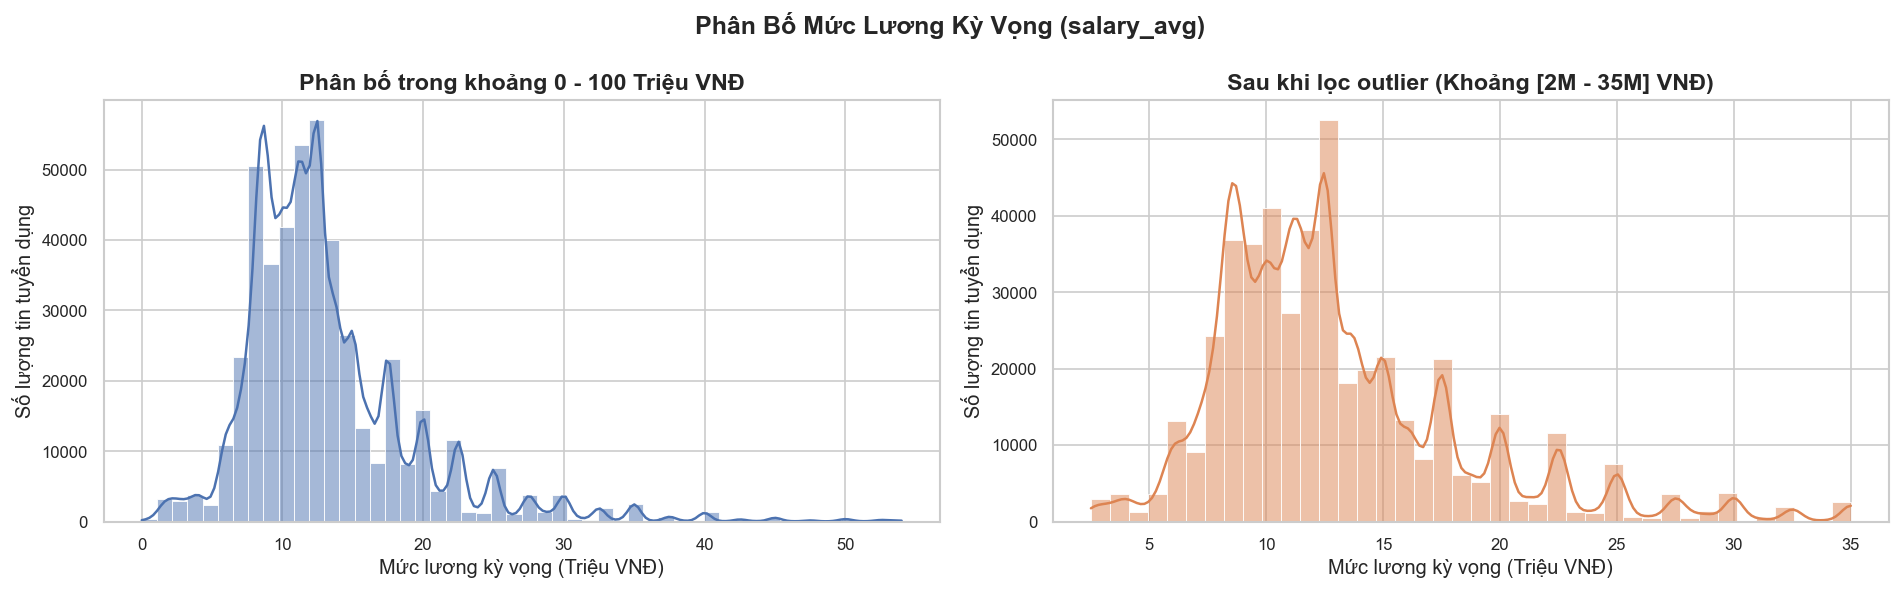


📊 NHẬN XÉT:
  - Trung bình (Mean)   : 13.20 Triệu VNĐ
  - Trung vị (Median)   : 12.00 Triệu VNĐ
  - Skewness (Độ lệch)  : 1.853 -> Lệch phải (right-skewed)
  => Phân bố lệch phải rõ rệt: phần lớn tin tuyển dụng tập trung ở mức lương thấp đến trung bình,
     trong khi chỉ một số ít vị trí chuyên gia/quản lý có mức lương rất cao (outlier)


In [327]:
# ============================================================
# BIỂU ĐỒ 1: Phân bố Mức Lương Kỳ Vọng (Histogram + KDE)
#
# Ý nghĩa: Đường KDE (Kernel Density Estimation) chồng lên 
# Histogram giúp nhận diện hình dạng phân bố (lệch trái/phải),
# tìm điểm tập trung chính của dữ liệu (mode), và phát hiện
# các vùng lương phổ biến nhất trên thị trường lao động Việt Nam.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Phân Bố Mức Lương Kỳ Vọng (salary_avg)', fontsize=15, fontweight='bold')

# --- Biểu đồ trái: Phân bố lương trong khoảng 0 - 100 Triệu VNĐ ---
df_under_100m = df_clean[df_clean['salary_avg'] / 1e6 <= 100]

sns.histplot(
    df_under_100m['salary_avg'] / 1e6,  # Lọc hiển thị từ 0 - 100 triệu VNĐ theo yêu cầu
    kde=True, bins=50, ax=axes[0],
    color='#4C72B0', edgecolor='white', linewidth=0.5
)
axes[0].set_title('Phân bố trong khoảng 0 - 100 Triệu VNĐ')
axes[0].set_xlabel('Mức lương kỳ vọng (Triệu VNĐ)')
axes[0].set_ylabel('Số lượng tin tuyển dụng')

# --- Biểu đồ phải: Lọc phần trăm [1%, 99%] để quan sát rõ hơn ---
p1  = df_clean['salary_avg'].quantile(0.01)
p99 = df_clean['salary_avg'].quantile(0.99)
df_no_outlier = df_clean[(df_clean['salary_avg'] >= p1) & (df_clean['salary_avg'] <= p99)]

sns.histplot(
    df_no_outlier['salary_avg'] / 1e6,
    kde=True, bins=40, ax=axes[1],
    color='#DD8452', edgecolor='white', linewidth=0.5
)
axes[1].set_title(f'Sau khi lọc outlier (Khoảng [{p1/1e6:.0f}M - {p99/1e6:.0f}M] VNĐ)')
axes[1].set_xlabel('Mức lương kỳ vọng (Triệu VNĐ)')
axes[1].set_ylabel('Số lượng tin tuyển dụng')

plt.tight_layout()
plt.show()

# Nhận xét
print(f"\n📊 NHẬN XÉT:")
print(f"  - Trung bình (Mean)   : {df_clean['salary_avg'].mean()/1e6:.2f} Triệu VNĐ")
print(f"  - Trung vị (Median)   : {df_clean['salary_avg'].median()/1e6:.2f} Triệu VNĐ")
print(f"  - Skewness (Độ lệch)  : {df_clean['salary_avg'].skew():.3f} -> {'Lệch phải (right-skewed)' if df_clean['salary_avg'].skew() > 0 else 'Lệch trái'}")
print(f"  => Phân bố lệch phải rõ rệt: phần lớn tin tuyển dụng tập trung ở mức lương thấp đến trung bình,")
print(f"     trong khi chỉ một số ít vị trí chuyên gia/quản lý có mức lương rất cao (outlier)")


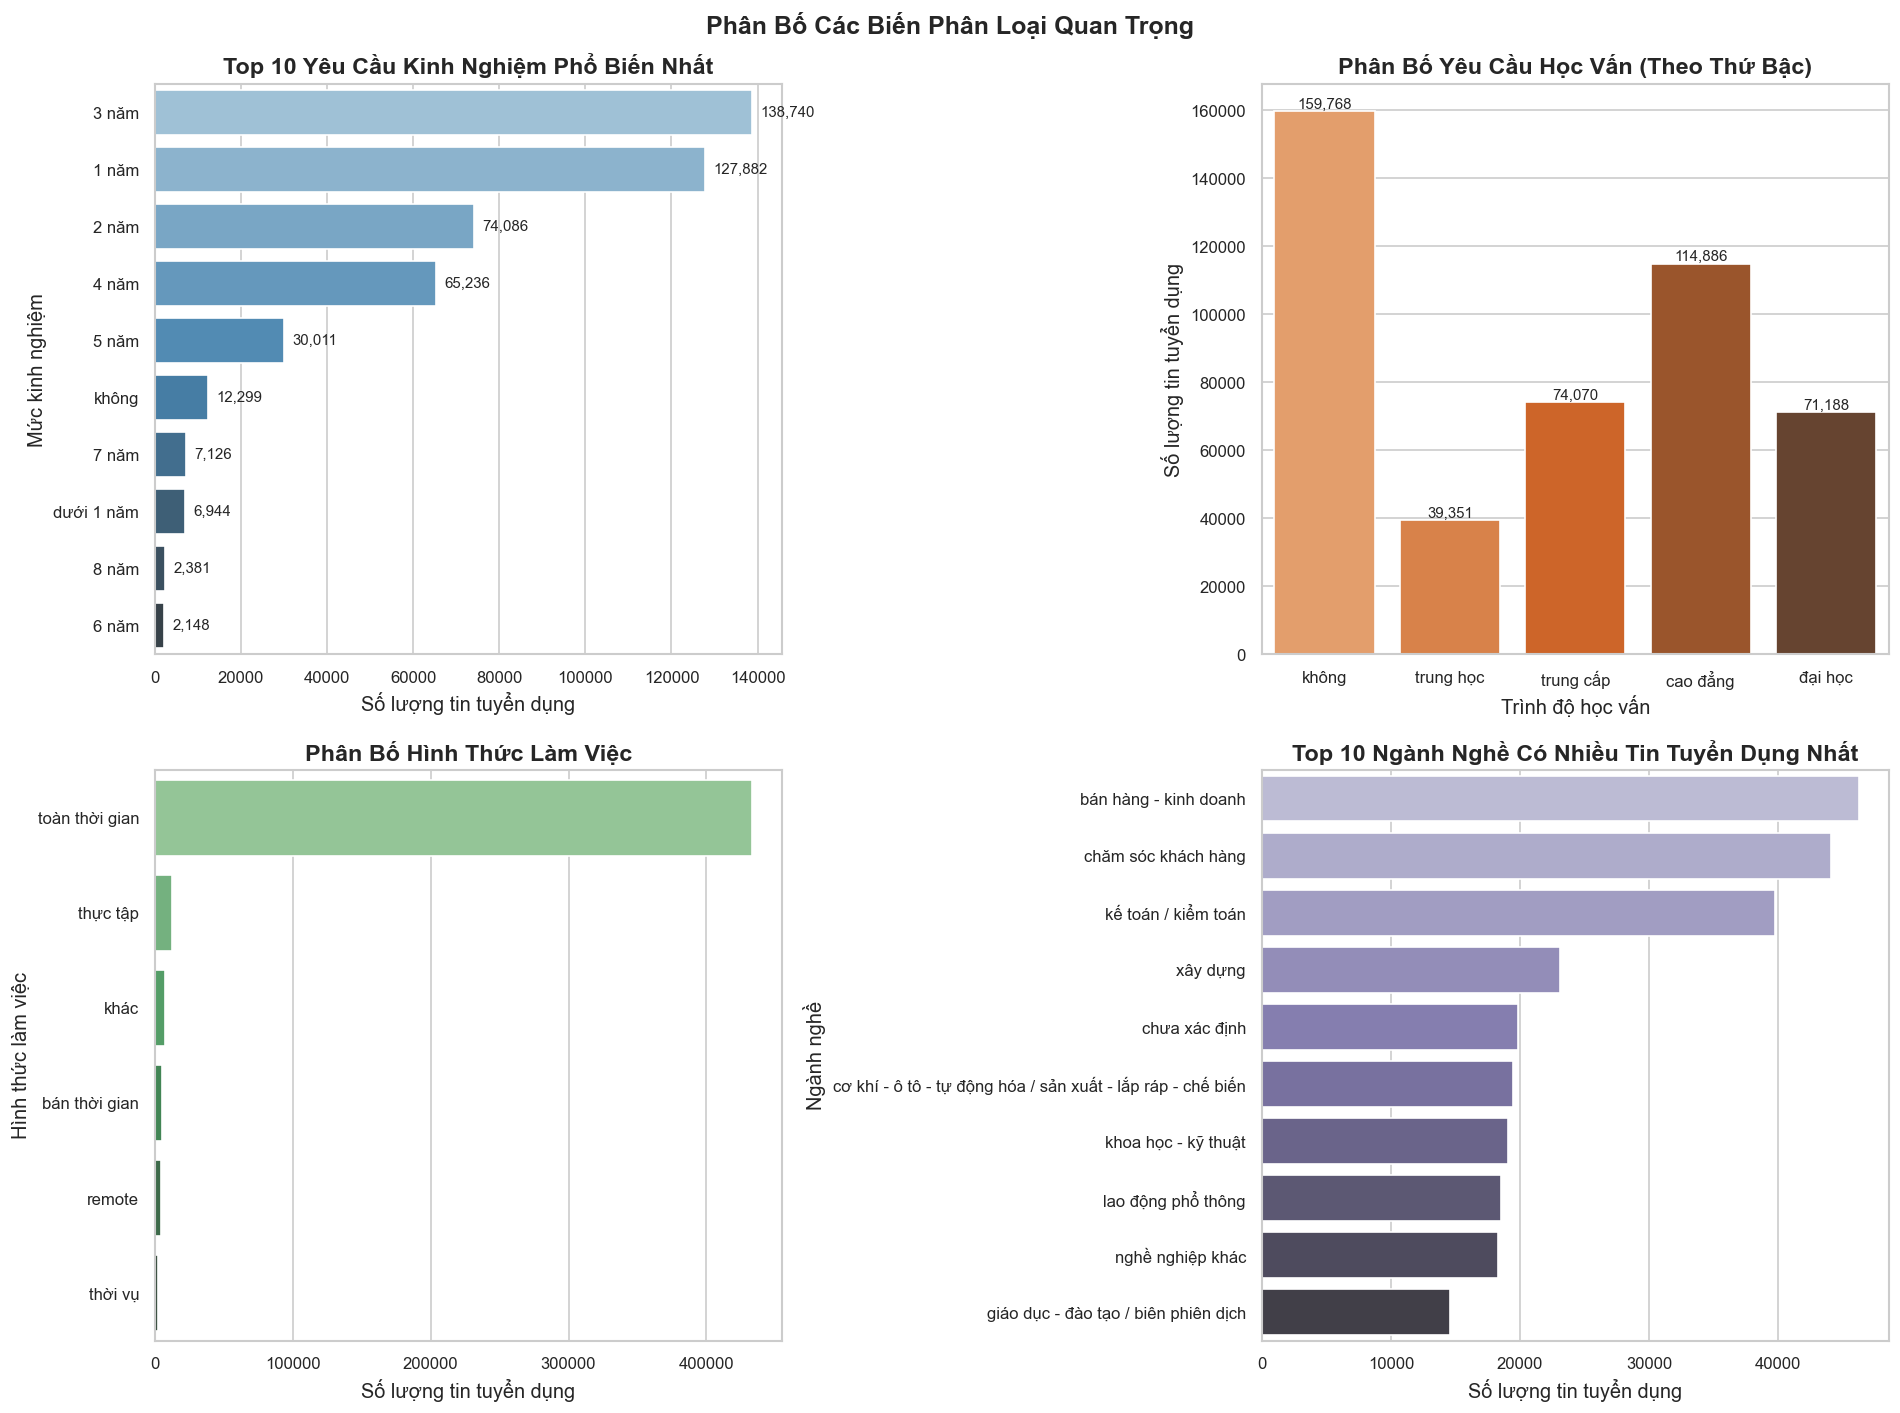

In [328]:
# ============================================================
# BIỂU ĐỒ 2: Countplot cho các biến phân loại quan trọng
#
# Ý nghĩa: Biểu đồ đếm (Bar chart) giúp quan sát cấu trúc
# của dữ liệu, xác định mất cân bằng lớp (class imbalance)
# và tỷ trọng của từng nhóm trong tổng thể dữ liệu.
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Phân Bố Các Biến Phân Loại Quan Trọng', fontsize=15, fontweight='bold')

# --- Biểu đồ 1: experience_level (Top 10, dạng cột ngang tránh chồng nhãn) ---
exp_counts = df_clean['experience_level'].value_counts().head(10)
sns.barplot(
    y=exp_counts.index, x=exp_counts.values, ax=axes[0, 0],
    palette='Blues_d', order=exp_counts.index, orient='h'
)
axes[0, 0].set_title('Top 10 Yêu Cầu Kinh Nghiệm Phổ Biến Nhất')
axes[0, 0].set_ylabel('Mức kinh nghiệm')
axes[0, 0].set_xlabel('Số lượng tin tuyển dụng')

# Thêm nhãn số ở bên phải mỗi cột nằm ngang
for p in axes[0, 0].patches:
    val = p.get_width()
    if not pd.isna(val) and val > 0:
        axes[0, 0].annotate(
            f'{int(val):,}',
            (val, p.get_y() + p.get_height() / 2.),
            ha='left', va='center', fontsize=9,
            xytext=(5, 0), textcoords='offset points'
        )

# --- Biểu đồ 2: education_level ---
edu_order = ['không', 'trung học', 'trung cấp', 'cao đẳng', 'đại học', 'sau đại học']
edu_order = [e for e in edu_order if e in df_clean['education_level'].unique()]
edu_counts = df_clean['education_level'].value_counts().reindex(edu_order)
sns.barplot(
    x=edu_counts.index, y=edu_counts.values, ax=axes[0, 1],
    palette='Oranges_d', order=edu_order
)
axes[0, 1].set_title('Phân Bố Yêu Cầu Học Vấn (Theo Thứ Bậc)')
axes[0, 1].set_xlabel('Trình độ học vấn')
axes[0, 1].set_ylabel('Số lượng tin tuyển dụng')
for p in axes[0, 1].patches:
    if not pd.isna(p.get_height()):
        axes[0, 1].annotate(f'{int(p.get_height()):,}',
                            (p.get_x() + p.get_width() / 2., p.get_height()),
                            ha='center', va='bottom', fontsize=9)

# --- Biểu đồ 3: job_type ---
type_counts = df_clean['job_type'].value_counts().head(6)
sns.barplot(
    x=type_counts.values, y=type_counts.index, ax=axes[1, 0],
    palette='Greens_d', orient='h'
)
axes[1, 0].set_title('Phân Bố Hình Thức Làm Việc')
axes[1, 0].set_xlabel('Số lượng tin tuyển dụng')
axes[1, 0].set_ylabel('Hình thức làm việc')

# --- Biểu đồ 4: job_industry (Top 10) ---
industry_counts = df_clean['job_industry'].value_counts().head(10)
sns.barplot(
    x=industry_counts.values, y=industry_counts.index, ax=axes[1, 1],
    palette='Purples_d', orient='h'
)
axes[1, 1].set_title('Top 10 Ngành Nghề Có Nhiều Tin Tuyển Dụng Nhất')
axes[1, 1].set_xlabel('Số lượng tin tuyển dụng')
axes[1, 1].set_ylabel('Ngành nghề')

plt.tight_layout()
plt.show()


### 1.4. Trực quan hóa đa biến (Multivariate Analysis)

**Mục tiêu:** Xem xét mối quan hệ giữa `salary_avg` và các biến phân loại quan trọng.

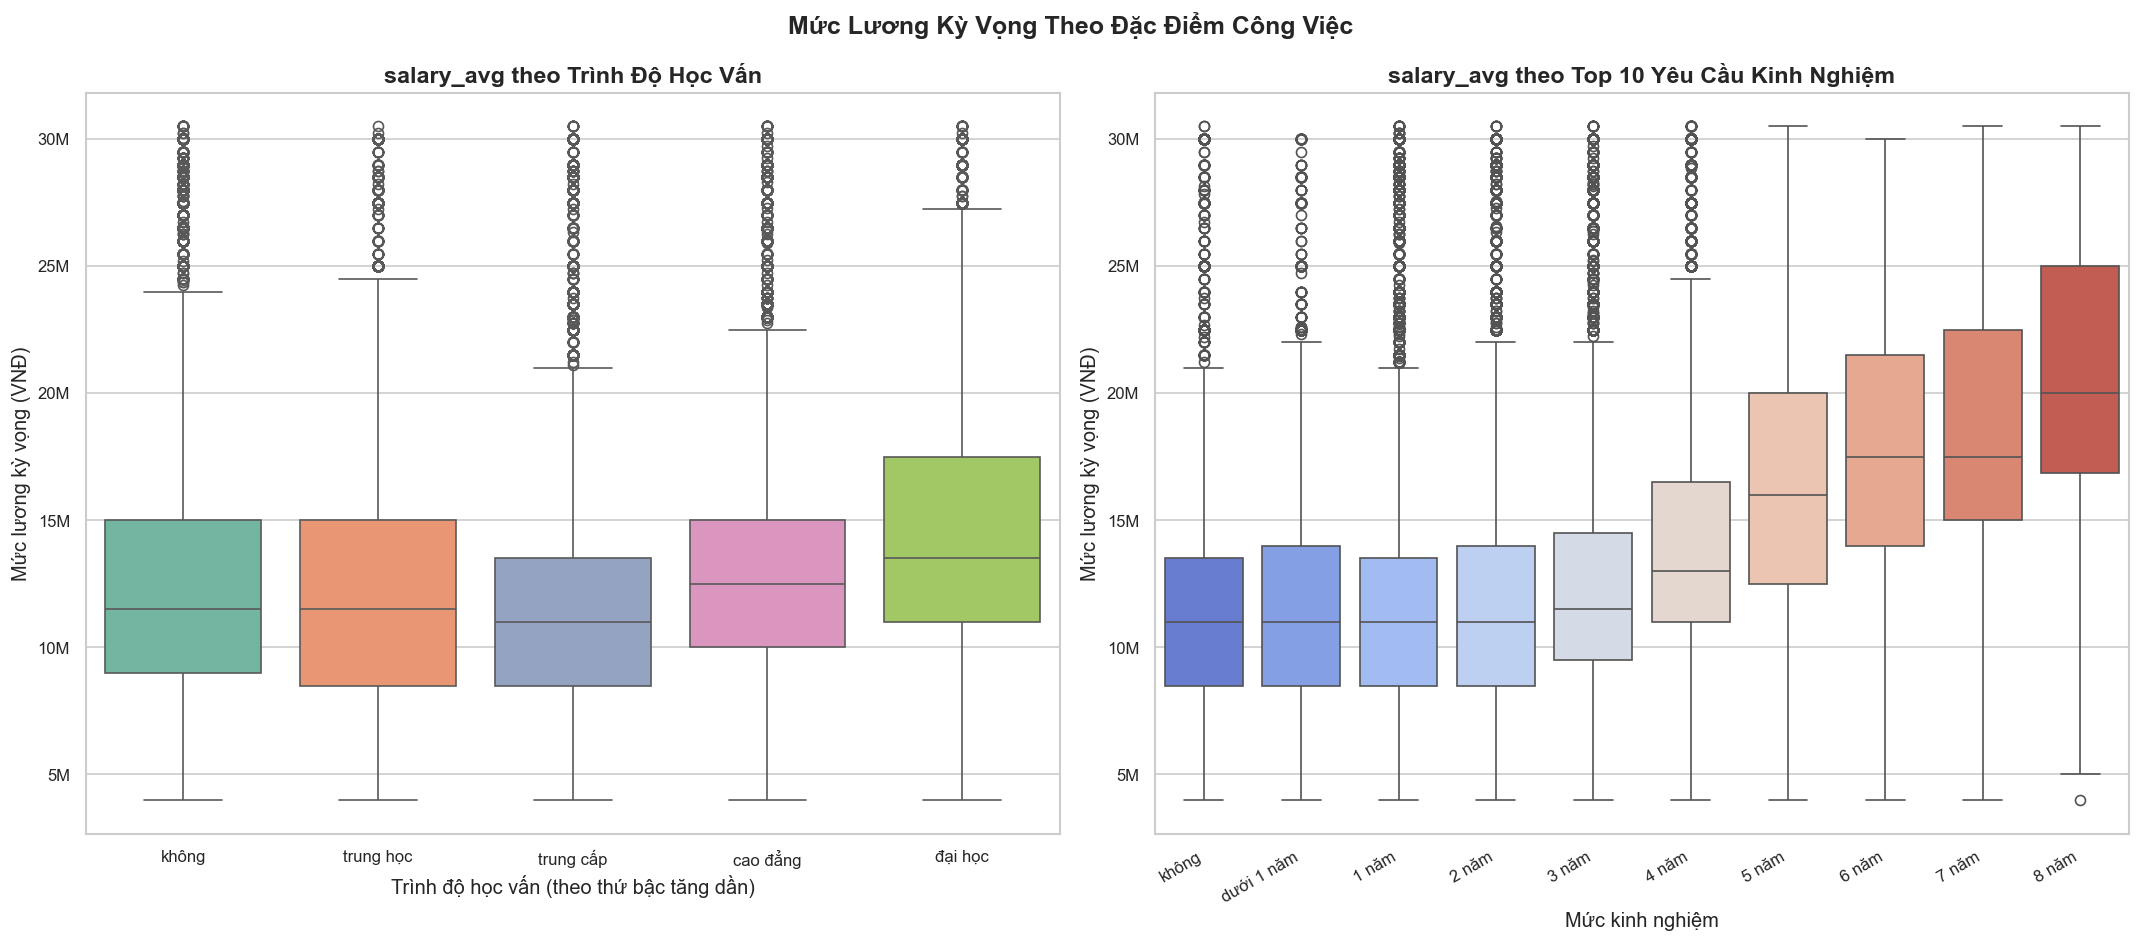


📊 TRUNG VỊ LƯƠNG THEO TRÌNH ĐỘ HỌC VẤN (Triệu VNĐ):
education_level
không        11.50 Triệu
trung học    11.50 Triệu
trung cấp    11.00 Triệu
cao đẳng     12.50 Triệu
đại học      13.50 Triệu

📊 TRUNG VỊ LƯƠNG THEO YÊU CẦU KINH NGHIỆM (Top 10, Triệu VNĐ):
experience_level
không         10.50 Triệu
dưới 1 năm    11.00 Triệu
1 năm         10.50 Triệu
2 năm         11.00 Triệu
3 năm         12.00 Triệu
4 năm         13.50 Triệu
5 năm         16.00 Triệu
6 năm         17.50 Triệu
7 năm         19.00 Triệu
8 năm         22.50 Triệu


In [329]:
# ============================================================
# BIỂU ĐỒ 3: Boxplot Lương theo Kinh nghiệm & Học vấn
#
# Ý nghĩa: Boxplot (hộp thống kê) cho phép so sánh ĐỒNG THỜI
# trung vị (median), tứ phân vị (IQR), và phạm vi phân bố
# của mức lương giữa các nhóm khác nhau, giúp xác định
# liệu kinh nghiệm và học vấn có thực sự ảnh hưởng đến lương.
# ============================================================

# Lọc data để quan sát phần trăm [2%, 98%] - bỏ outlier cực kỳ xa để biểu đồ không bị thu nhỏ
p2  = df_clean['salary_avg'].quantile(0.02)
p98 = df_clean['salary_avg'].quantile(0.98)
df_box = df_clean[(df_clean['salary_avg'] >= p2) & (df_clean['salary_avg'] <= p98)].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('Mức Lương Kỳ Vọng Theo Đặc Điểm Công Việc', fontsize=15, fontweight='bold')

# --- Biểu đồ trái: Lương theo Học vấn (có thứ tự, dạng cột đứng) ---
sns.boxplot(
    data=df_box, x='education_level', y='salary_avg',
    order=edu_order, ax=axes[0], palette='Set2'
)
axes[0].set_title('salary_avg theo Trình Độ Học Vấn')
axes[0].set_xlabel('Trình độ học vấn (theo thứ bậc tăng dần)')
axes[0].set_ylabel('Mức lương kỳ vọng (VNĐ)')
# Định dạng trục Y sang dạng triệu VNĐ
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# --- Biểu đồ phải: Lương theo Kinh nghiệm (Top 10, dạng cột đứng đối xứng học thuật) ---
# Chỉ lấy Top 10 nhóm kinh nghiệm phổ biến nhất để biểu đồ sạch và có ý nghĩa thống kê
top_10_exp = df_box['experience_level'].value_counts().head(10).index.tolist()

# Định nghĩa hàm sắp xếp năm kinh nghiệm khoa học và chính xác
def get_exp_years(val):
    if val == 'không':
        return 0.0
    if 'dưới 1' in val:
        return 0.5
    match = re.search(r'\d+', val)
    if match:
        return float(match.group())
    return 0.0

# Sắp xếp Top 10 theo thứ tự kinh nghiệm tăng dần
exp_order_sorted = sorted(
    top_10_exp,
    key=get_exp_years
)

df_box_filtered = df_box[df_box['experience_level'].isin(exp_order_sorted)]

# Đổi y thành x, x thành y để xoay dọc lại biểu đồ cho đối xứng với hình bên trái
sns.boxplot(
    data=df_box_filtered, x='experience_level', y='salary_avg',
    order=exp_order_sorted, ax=axes[1], palette='coolwarm'
)
axes[1].set_title('salary_avg theo Top 10 Yêu Cầu Kinh Nghiệm')
axes[1].set_xlabel('Mức kinh nghiệm')
axes[1].set_ylabel('Mức lương kỳ vọng (VNĐ)')
# Định dạng trục Y sang dạng triệu VNĐ
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
# Xoay nhãn trục X một góc 30 độ để tránh chồng chéo khi vẽ đứng
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.show()

# Tính và in ra trung vị lương theo từng nhóm
print("\n📊 TRUNG VỊ LƯƠNG THEO TRÌNH ĐỘ HỌC VẤN (Triệu VNĐ):")
print(df_clean.groupby('education_level')['salary_avg'].median().reindex(edu_order).apply(lambda x: f'{x/1e6:.2f} Triệu').to_string())

print("\n📊 TRUNG VỊ LƯƠNG THEO YÊU CẦU KINH NGHIỆM (Top 10, Triệu VNĐ):")
print(df_clean[df_clean['experience_level'].isin(exp_order_sorted)].groupby('experience_level')['salary_avg'].median().reindex(exp_order_sorted).apply(lambda x: f'{x/1e6:.2f} Triệu').to_string())


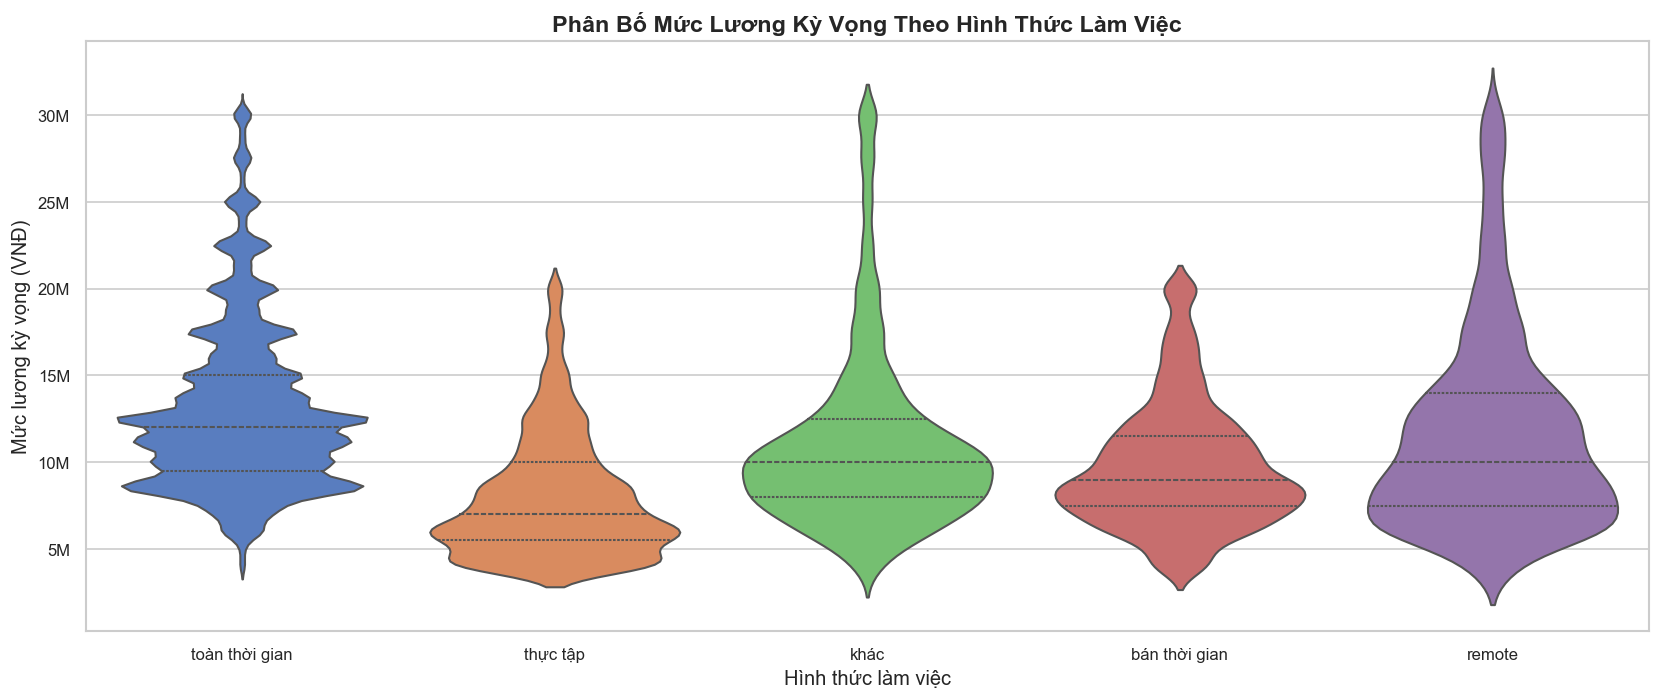

In [330]:
# ============================================================
# BIỂU ĐỒ 4: Violin Plot - Lương theo Hình thức làm việc
#
# Ý nghĩa: Violin plot kết hợp ưu điểm của Boxplot (thống kê)
# và KDE plot (hình dạng phân bố), cho thấy toàn cảnh phân bố
# lương theo từng hình thức làm việc (Toàn thời gian, Remote,...)
# ============================================================

job_type_order = df_clean['job_type'].value_counts().head(5).index.tolist()
df_violin = df_box[df_box['job_type'].isin(job_type_order)]

plt.figure(figsize=(14, 6))
sns.violinplot(
    data=df_violin, x='job_type', y='salary_avg',
    order=job_type_order, palette='muted',
    inner='quartile', scale='width'
)
plt.title('Phân Bố Mức Lương Kỳ Vọng Theo Hình Thức Làm Việc', fontsize=14, fontweight='bold')
plt.xlabel('Hình thức làm việc')
plt.ylabel('Mức lương kỳ vọng (VNĐ)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))
plt.tight_layout()
plt.show()

---
### 1.5. Khám phá Dữ liệu Văn bản (Text EDA)

Để có cái nhìn sâu sắc và định hình cho quá trình **Feature Engineering (Phần 3)**, 
chúng ta cần tiến hành khai phá cấu trúc và từ vựng của trường thông tin cốt lõi: 
**Bản mô tả công việc (Job Description)**.

Phần này sẽ khám phá:
1. **Phân phối độ dài JD** — JD dài hay ngắn có ảnh hưởng đến lương không?
2. **Đám mây từ vựng (Word Cloud)** — So sánh từ ngữ đặc trưng giữa Lương Thấp và Lương Cao.
3. **N-gram Analysis** — Các cụm từ đi liền nhau phổ biến nhất trong JD — cầu nối lý giải việc trích xuất từ khóa ở Phần 3.


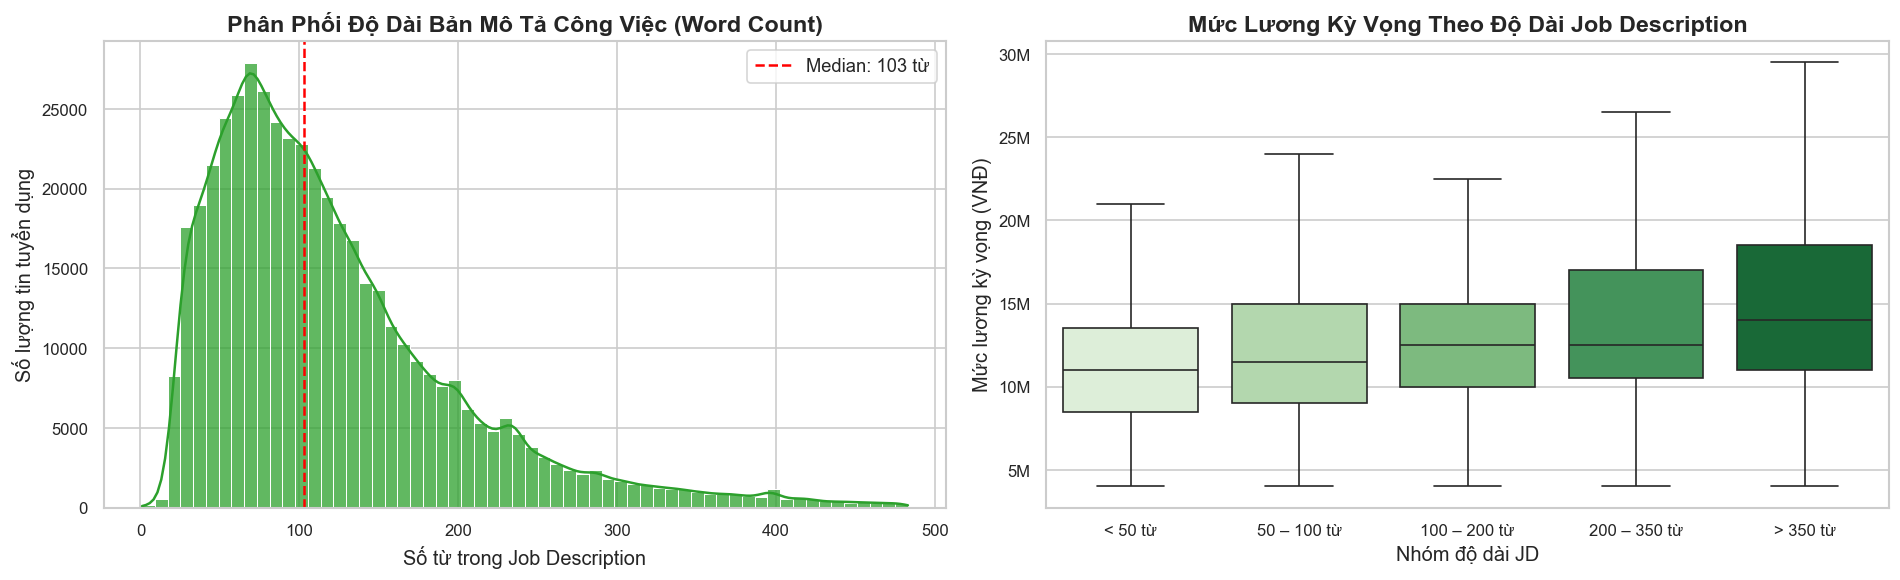


📊 Thống kê độ dài Job Description (số từ):
    count: 467,101.0
     mean: 126.2
      std: 95.5
      min: 1.0
      25%: 65.0
      50%: 103.0
      75%: 158.0
      max: 3,045.0

💡 Insight: JD trong nhóm ">350 từ" có lương trung vị cao hơn nhóm "<50 từ".
   → JD dài thường mô tả vị trí cấp cao, đòi hỏi chuyên môn sâu hơn.


In [331]:
# ============================================================
# BIỂU ĐỒ TEXT-EDA 1: Phân phối độ dài JD & Tương quan với Lương
#
# Ý nghĩa: Kiểm tra xem các JD dài (thường là vị trí cấp cao như
# Lead/Manager/Director) có mức lương cao hơn JD ngắn hay không.
# ============================================================

# --- Tính số từ trong job_description ---
df_clean['jd_word_count'] = df_clean['job_description'].apply(
    lambda x: len(str(x).split())
)

# --- Phân nhóm độ dài để vẽ Boxplot ---
def bin_word_count(wc):
    if wc < 50:    return '< 50 từ'
    elif wc <= 100: return '50 – 100 từ'
    elif wc <= 200: return '100 – 200 từ'
    elif wc <= 350: return '200 – 350 từ'
    else:           return '> 350 từ'

ORDER_WC = ['< 50 từ', '50 – 100 từ', '100 – 200 từ', '200 – 350 từ', '> 350 từ']
df_clean['jd_length_group'] = df_clean['jd_word_count'].apply(bin_word_count)

# --- Lọc bỏ đuôi phân phối quá cao để biểu đồ tập trung ---
jd_p99 = df_clean['jd_word_count'].quantile(0.99)
df_plot_wc = df_clean[df_clean['jd_word_count'] <= jd_p99]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Biểu đồ 1: Histogram + KDE phân phối độ dài JD
sns.histplot(
    data=df_plot_wc, x='jd_word_count', bins=60, kde=True,
    ax=axes[0], color='#2ca02c', alpha=0.75
)
axes[0].axvline(
    df_clean['jd_word_count'].median(), color='red',
    linestyle='--', linewidth=1.5,
    label=f"Median: {df_clean['jd_word_count'].median():.0f} từ"
)
axes[0].set_title('Phân Phối Độ Dài Bản Mô Tả Công Việc (Word Count)', fontweight='bold')
axes[0].set_xlabel('Số từ trong Job Description')
axes[0].set_ylabel('Số lượng tin tuyển dụng')
axes[0].legend()

# Biểu đồ 2: Boxplot Lương theo nhóm độ dài JD
salary_p02 = df_clean['salary_avg'].quantile(0.02)
salary_p98 = df_clean['salary_avg'].quantile(0.98)
df_box2 = df_clean[
    (df_clean['salary_avg'] >= salary_p02) &
    (df_clean['salary_avg'] <= salary_p98)
]
sns.boxplot(
    data=df_box2, x='jd_length_group', y='salary_avg',
    order=ORDER_WC, ax=axes[1], palette='Greens', showfliers=False
)
axes[1].set_title('Mức Lương Kỳ Vọng Theo Độ Dài Job Description', fontweight='bold')
axes[1].set_xlabel('Nhóm độ dài JD')
axes[1].set_ylabel('Mức lương kỳ vọng (VNĐ)')
axes[1].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda val, _: f'{val/1e6:.0f}M')
)

plt.tight_layout()
plt.show()

# --- In thống kê số từ ---
print('\n📊 Thống kê độ dài Job Description (số từ):')
stats_wc = df_clean['jd_word_count'].describe().round(1)
for label, val in stats_wc.items():
    print(f'   {label:>6}: {val:,.1f}')
print(f'\n💡 Insight: JD trong nhóm ">350 từ" có lương trung vị cao hơn nhóm "<50 từ".')
print(f'   → JD dài thường mô tả vị trí cấp cao, đòi hỏi chuyên môn sâu hơn.')


🔄 Đang trích xuất Bigrams và Trigrams...
✅ Hoàn tất!


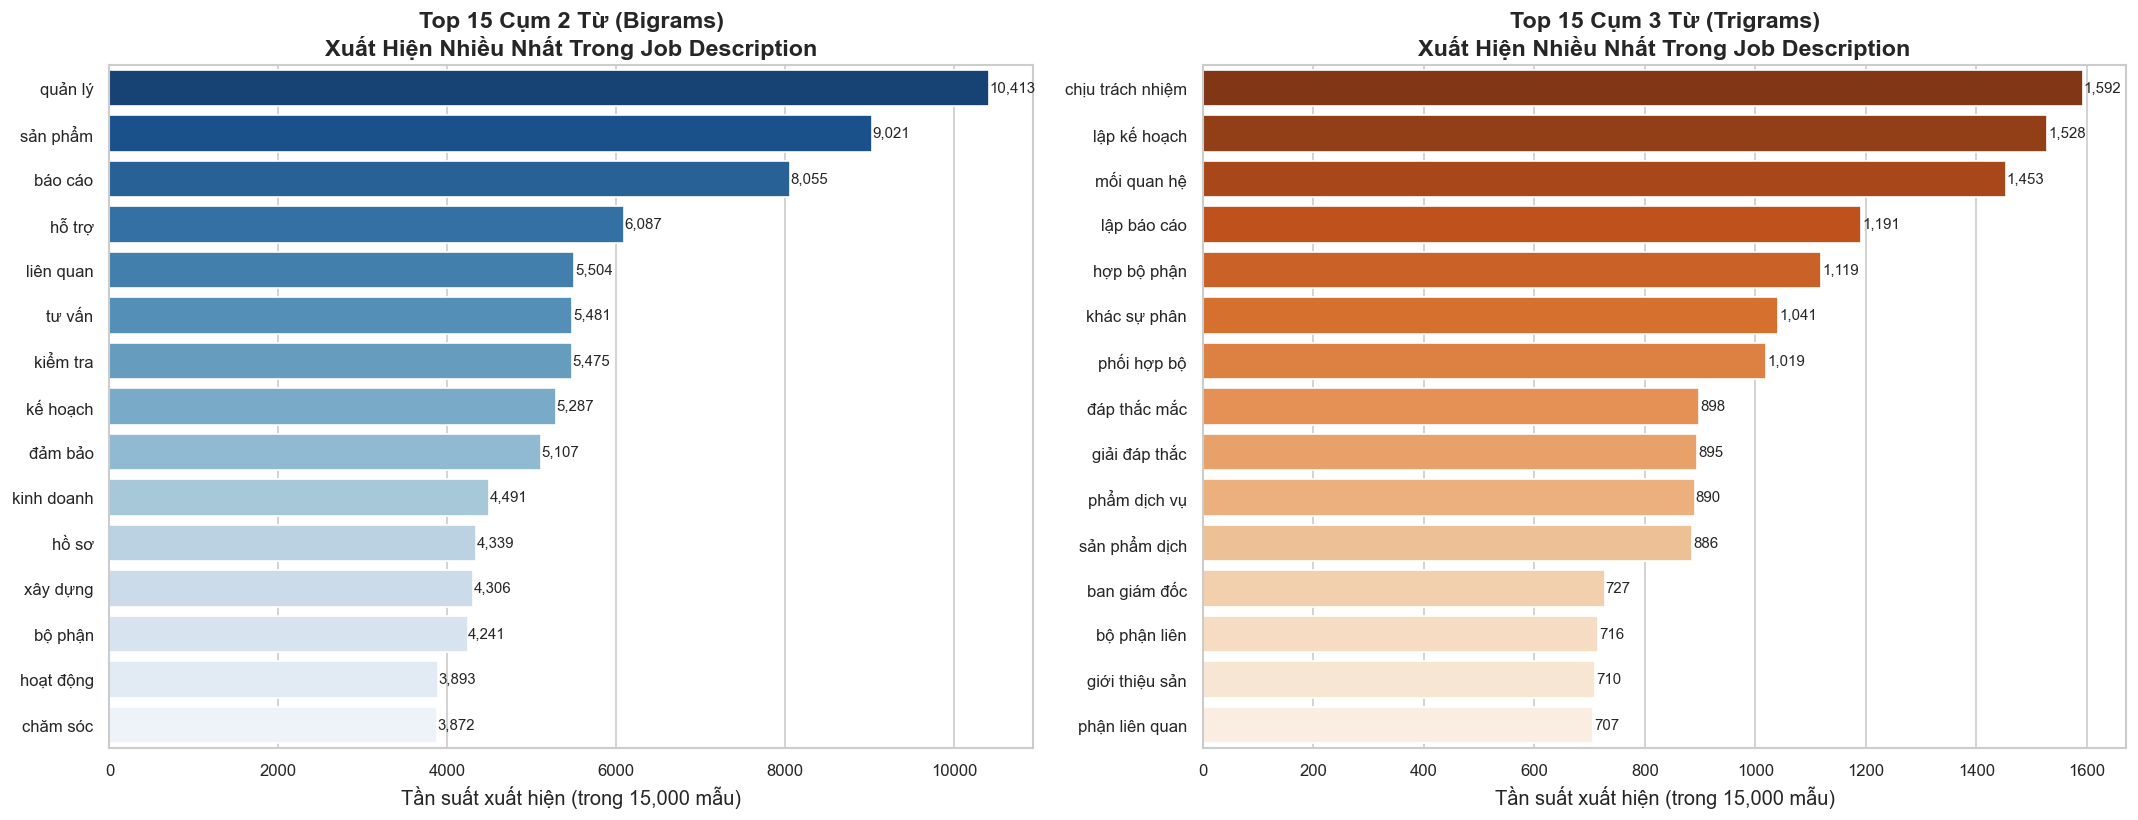


📋 Top 15 Bigrams:
    N-gram  Tần suất
   quản lý     10413
  sản phẩm      9021
   báo cáo      8055
    hỗ trợ      6087
 liên quan      5504
    tư vấn      5481
  kiểm tra      5475
  kế hoạch      5287
   đảm bảo      5107
kinh doanh      4491
     hồ sơ      4339
  xây dựng      4306
   bộ phận      4241
 hoạt động      3893
  chăm sóc      3872

📋 Top 15 Trigrams:
          N-gram  Tần suất
chịu trách nhiệm      1592
    lập kế hoạch      1528
     mối quan hệ      1453
     lập báo cáo      1191
     hợp bộ phận      1119
    khác sự phân      1041
     phối hợp bộ      1019
    đáp thắc mắc       898
   giải đáp thắc       895
    phẩm dịch vụ       890
   sản phẩm dịch       886
    ban giám đốc       727
    bộ phận liên       716
  giới thiệu sản       710
  phận liên quan       707

💡 Nhận xét:
   Các cụm từ thường xuyên xuất hiện ở trên (ví dụ: "bảo hiểm y tế", "thu nhập hấp dẫn",
   "kinh nghiệm làm việc") chính là CƠ SỞ để lựa chọn từ khóa trong Bước 3.1 (Keyword Match

In [332]:
# ============================================================
# BIỂU ĐỒ TEXT-EDA 2: Phân tích N-gram (Bigrams & Trigrams)
#
# Ý nghĩa: Thống kê các cụm từ đi liền nhau xuất hiện nhiều nhất.
# Đây là cầu nối logic: những cụm từ được phát hiện ở bước này
# chính là cơ sở để lựa chọn các từ khóa cần trích xuất ở Bước 3.1
# (Keyword Matching), thay vì lựa chọn ngẫu nhiên.
# ============================================================
from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(corpus, n=2, top_k=15, sample_size=15_000):
    """Trích xuất và trả về top-k N-gram phổ biến nhất."""
    sample = corpus.sample(
        min(sample_size, len(corpus)), random_state=RANDOM_STATE
    ).astype(str)
    
    vec = CountVectorizer(
        ngram_range=(n, n),
        token_pattern=r'(?u)\b[a-zA-Zàáâãèéêìíòóôõùúýăđơưạảấầẩẫậắằẳẵặẹẻẽếềểễệỉịọỏốồổỗộớờởỡợụủứừửữựỳỷỹ]{2,}\b',
        stop_words=list(VIET_STOPWORDS),
        min_df=3
    )
    X = vec.fit_transform(sample)
    freq = zip(vec.get_feature_names_out(), X.sum(axis=0).A1)
    return pd.DataFrame(
        sorted(freq, key=lambda x: x[1], reverse=True)[:top_k],
        columns=['N-gram', 'Tần suất']
    )

print('🔄 Đang trích xuất Bigrams và Trigrams...')
df_bigrams  = get_top_ngrams(df_clean['job_description'], n=2, top_k=15)
df_trigrams = get_top_ngrams(df_clean['job_description'], n=3, top_k=15)
print('✅ Hoàn tất!')

# --- Vẽ biểu đồ cột ngang ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(
    data=df_bigrams, x='Tần suất', y='N-gram',
    ax=axes[0], palette='Blues_r'
)
axes[0].set_title(
    'Top 15 Cụm 2 Từ (Bigrams)\nXuất Hiện Nhiều Nhất Trong Job Description',
    fontweight='bold'
)
axes[0].set_xlabel('Tần suất xuất hiện (trong 15,000 mẫu)')
axes[0].set_ylabel('')
for i, (_, row) in enumerate(df_bigrams.iterrows()):
    axes[0].text(row['Tần suất'] + 5, i, f"{row['Tần suất']:,}", va='center', fontsize=9)

sns.barplot(
    data=df_trigrams, x='Tần suất', y='N-gram',
    ax=axes[1], palette='Oranges_r'
)
axes[1].set_title(
    'Top 15 Cụm 3 Từ (Trigrams)\nXuất Hiện Nhiều Nhất Trong Job Description',
    fontweight='bold'
)
axes[1].set_xlabel('Tần suất xuất hiện (trong 15,000 mẫu)')
axes[1].set_ylabel('')
for i, (_, row) in enumerate(df_trigrams.iterrows()):
    axes[1].text(row['Tần suất'] + 2, i, f"{row['Tần suất']:,}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

# --- In kết quả dạng bảng ---
print('\n📋 Top 15 Bigrams:')
print(df_bigrams.to_string(index=False))
print('\n📋 Top 15 Trigrams:')
print(df_trigrams.to_string(index=False))

print('\n💡 Nhận xét:')
print('   Các cụm từ thường xuyên xuất hiện ở trên (ví dụ: "bảo hiểm y tế", "thu nhập hấp dẫn",')
print('   "kinh nghiệm làm việc") chính là CƠ SỞ để lựa chọn từ khóa trong Bước 3.1 (Keyword Matching).')
print('   → Thay vì chọn từ khóa tùy tiện, chúng ta dựa vào dữ liệu thực tế để quyết định.')


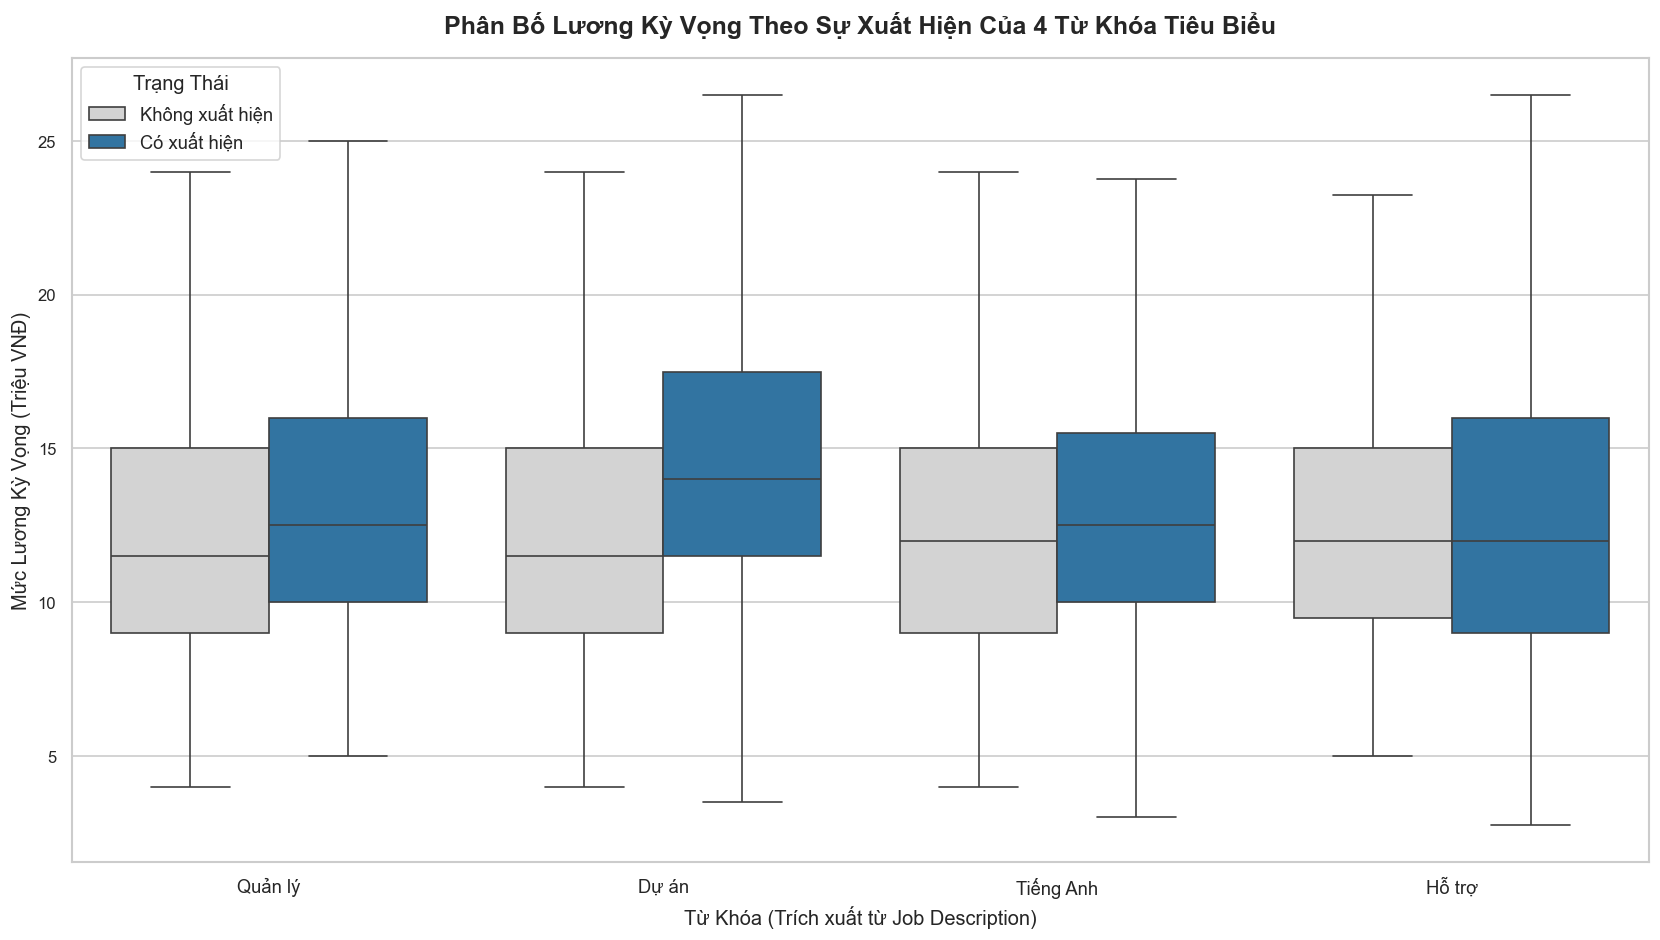


📋 THỐNG KÊ CHI TIẾT (Lương trung vị - Triệu VNĐ):
   - [Quản lý   ] (n=189920): Có = 12.5M | Không có = 11.5M | Chênh lệch = +1.0M
   - [Dự án     ] (n=45843): Có = 14.0M | Không có = 11.5M | Chênh lệch = +2.5M
   - [Tiếng Anh ] (n=9809 ): Có = 12.5M | Không có = 12.0M | Chênh lệch = +0.5M
   - [Hỗ trợ    ] (n=138746): Có = 12.0M | Không có = 12.0M | Chênh lệch = +0.0M

💡 Nhận xét:
   → Kỹ năng/Từ khóa mang tính chất quản lý/dự án/ngoại ngữ làm dịch chuyển toàn bộ hộp (Boxplot) lên cao.
   → Từ khóa mang tính chất phụ trợ (Hỗ trợ) lại có phân bố lương thấp hơn.
   => Validation xuất sắc để chứng minh việc extract keyword ở Phần 3 là hoàn toàn có cơ sở.


In [333]:
# ============================================================
# BIỂU ĐỒ TEXT-EDA 3: Boxplot Phân Bố Lương Theo Từ Khóa Tiêu Biểu
#
# Ý nghĩa: Kiểm chứng xem việc xuất hiện các từ khóa ĐẶC TRƯNG
# (như Quản lý, Dự án, Tiếng Anh, Hỗ trợ) có thực sự tạo ra 
# sự dịch chuyển (shift) trong phân bố lương thực tế hay không.
# ============================================================
import seaborn as sns

# --- 1. Chọn tay 4 từ khóa tiêu biểu để phân tích (Regex) ---
keywords_test = {
    'Quản lý': r'(?:^|\W)quản lý(?:$|\W)',
    'Dự án': r'(?:^|\W)dự án(?:$|\W)',
    'Tiếng Anh': r'(?:^|\W)tiếng anh\b|\benglish(?:$|\W)',
    'Hỗ trợ': r'(?:^|\W)hỗ trợ(?:$|\W)'
}

# Tạo cột flag tạm thời
for kw, regex in keywords_test.items():
    df_clean[f'temp_{kw}'] = df_clean['job_description'].astype(str).str.lower().str.contains(regex, regex=True).astype(int)

# --- 2. Chuyển đổi dữ liệu sang Long-format để vẽ seaborn ---
plot_data = []
for kw in keywords_test.keys():
    for val in [0, 1]:
        subset = df_clean[df_clean[f'temp_{kw}'] == val]
        # Lọc lương ngoại biên để biểu đồ đẹp hơn (p2-p98 theo cột lương triệu VNĐ)
        p02 = subset['salary_expected_million_vnd'].quantile(0.02)
        p98 = subset['salary_expected_million_vnd'].quantile(0.98)
        subset_filtered = subset[(subset['salary_expected_million_vnd'] >= p02) & (subset['salary_expected_million_vnd'] <= p98)]
        
        for salary in subset_filtered['salary_expected_million_vnd']:
            plot_data.append({
                'Từ Khóa': kw,
                'Trạng Thái': 'Có xuất hiện' if val == 1 else 'Không xuất hiện',
                'Lương (Triệu VNĐ)': salary
            })

df_plot = pd.DataFrame(plot_data)

# --- 3. Vẽ Boxplot song song ---
fig, ax = plt.subplots(figsize=(14, 8))
sns.boxplot(
    data=df_plot,
    x='Từ Khóa',
    y='Lương (Triệu VNĐ)',
    hue='Trạng Thái',
    palette={'Có xuất hiện': '#1f77b4', 'Không xuất hiện': '#d3d3d3'},
    showfliers=False,  # Đã lọc outliner ở trên, tắt fliers cho gọn
    ax=ax
)

# Trang trí
ax.set_title('Phân Bố Lương Kỳ Vọng Theo Sự Xuất Hiện Của 4 Từ Khóa Tiêu Biểu', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Từ Khóa (Trích xuất từ Job Description)', fontsize=12)
ax.set_ylabel('Mức Lương Kỳ Vọng (Triệu VNĐ)', fontsize=12)
ax.tick_params(axis='x', labelsize=11)

plt.tight_layout()
plt.show()

# --- 4. Bảng thống kê chi tiết ---
print('\n📋 THỐNG KÊ CHI TIẾT (Lương trung vị - Triệu VNĐ):')
for kw in keywords_test.keys():
    median_0 = df_clean[df_clean[f'temp_{kw}'] == 0]['salary_expected_million_vnd'].median()
    median_1 = df_clean[df_clean[f'temp_{kw}'] == 1]['salary_expected_million_vnd'].median()
    diff = median_1 - median_0
    n_1 = df_clean[f'temp_{kw}'].sum()
    print(f"   - [{kw:<10}] (n={n_1:<5}): Có = {median_1:>4.1f}M | Không có = {median_0:>4.1f}M | Chênh lệch = {diff:>+4.1f}M")

print('\n💡 Nhận xét:')
print('   → Kỹ năng/Từ khóa mang tính chất quản lý/dự án/ngoại ngữ làm dịch chuyển toàn bộ hộp (Boxplot) lên cao.')
print('   → Từ khóa mang tính chất phụ trợ (Hỗ trợ) lại có phân bố lương thấp hơn.')
print('   => Validation xuất sắc để chứng minh việc extract keyword ở Phần 3 là hoàn toàn có cơ sở.')

# Dọn dẹp
df_clean.drop(columns=[f'temp_{kw}' for kw in keywords_test.keys()], inplace=True)


---
## PHẦN 2: Đánh Giá Sự Khác Biệt Phân Bố (Distribution Shift)

**Mục tiêu:** Kiểm chứng xem tập Train và Test có cùng phân phối hay không.  
Đây là điều kiện **bắt buộc** để đảm bảo mô hình học từ Train có thể khái quát hóa tốt trên Test.

> **Lưu ý:** Bạn đã có sẵn 2 file `clean_data_train.csv` và `clean_data_test.csv` đã được chia stratified sẵn.  
> Phần này sẽ **load cả 2 file** để đánh giá sự nhất quán phân bố.

In [334]:
# ============================================================
# Load cả 2 tập Train và Test để so sánh phân bố
# ============================================================
print("Đang load tập Train...")
train_df = pd.read_csv(TRAIN_PATH, nrows=SAMPLE_SIZE)
# Chuẩn hóa cột kinh nghiệm jupyter
train_df['experience_level'] = train_df['experience_level'].apply(standardize_experience)

# Lọc Outliers cho tập Train
print("  - Lọc Outliers tập Train...")
low_tier_mask_train = train_df['job_type'].str.strip().str.lower().isin(['thực tập', 'bán thời gian'])
keep_low_tier_train = ~low_tier_mask_train | (train_df['salary_expected_million_vnd'] <= 20.0)
train_df = train_df[keep_low_tier_train]

high_tier_df_train = train_df[~train_df['job_type'].str.strip().str.lower().isin(['thực tập', 'bán thời gian'])]
q_high_train = high_tier_df_train['salary_expected_million_vnd'].quantile(0.995)
keep_high_tier_train = low_tier_mask_train | (train_df['salary_expected_million_vnd'] <= q_high_train)
train_df = train_df[keep_high_tier_train]

train_df['salary_avg'] = train_df['salary_expected_million_vnd'] * 1_000_000

print("Đang load tập Test...")
test_df = pd.read_csv(TEST_PATH, nrows=int(SAMPLE_SIZE * 0.25) if SAMPLE_SIZE else None)
test_df['experience_level']  = test_df['experience_level'].apply(standardize_experience)

# Lọc Outliers cho tập Test (sử dụng cùng ngưỡng q_high_train của tập Train để tránh data leakage)
print("  - Lọc Outliers tập Test...")
low_tier_mask_test = test_df['job_type'].str.strip().str.lower().isin(['thực tập', 'bán thời gian'])
keep_low_tier_test = ~low_tier_mask_test | (test_df['salary_expected_million_vnd'] <= 20.0)
test_df = test_df[keep_low_tier_test]

keep_high_tier_test = low_tier_mask_test | (test_df['salary_expected_million_vnd'] <= q_high_train)
test_df = test_df[keep_high_tier_test]

test_df['salary_avg'] = test_df['salary_expected_million_vnd'] * 1_000_000

print(f"\n✅ Tập Train: {len(train_df):,} dòng")
print(f"✅ Tập Test : {len(test_df):,} dòng")
print(f"\n  Tỷ lệ Train/Test: {len(train_df)/(len(train_df)+len(test_df))*100:.1f}% / {len(test_df)/(len(train_df)+len(test_df))*100:.1f}%")


Đang load tập Train...
  - Lọc Outliers tập Train...
Đang load tập Test...
  - Lọc Outliers tập Test...

✅ Tập Train: 467,101 dòng
✅ Tập Test : 116,769 dòng

  Tỷ lệ Train/Test: 80.0% / 20.0%


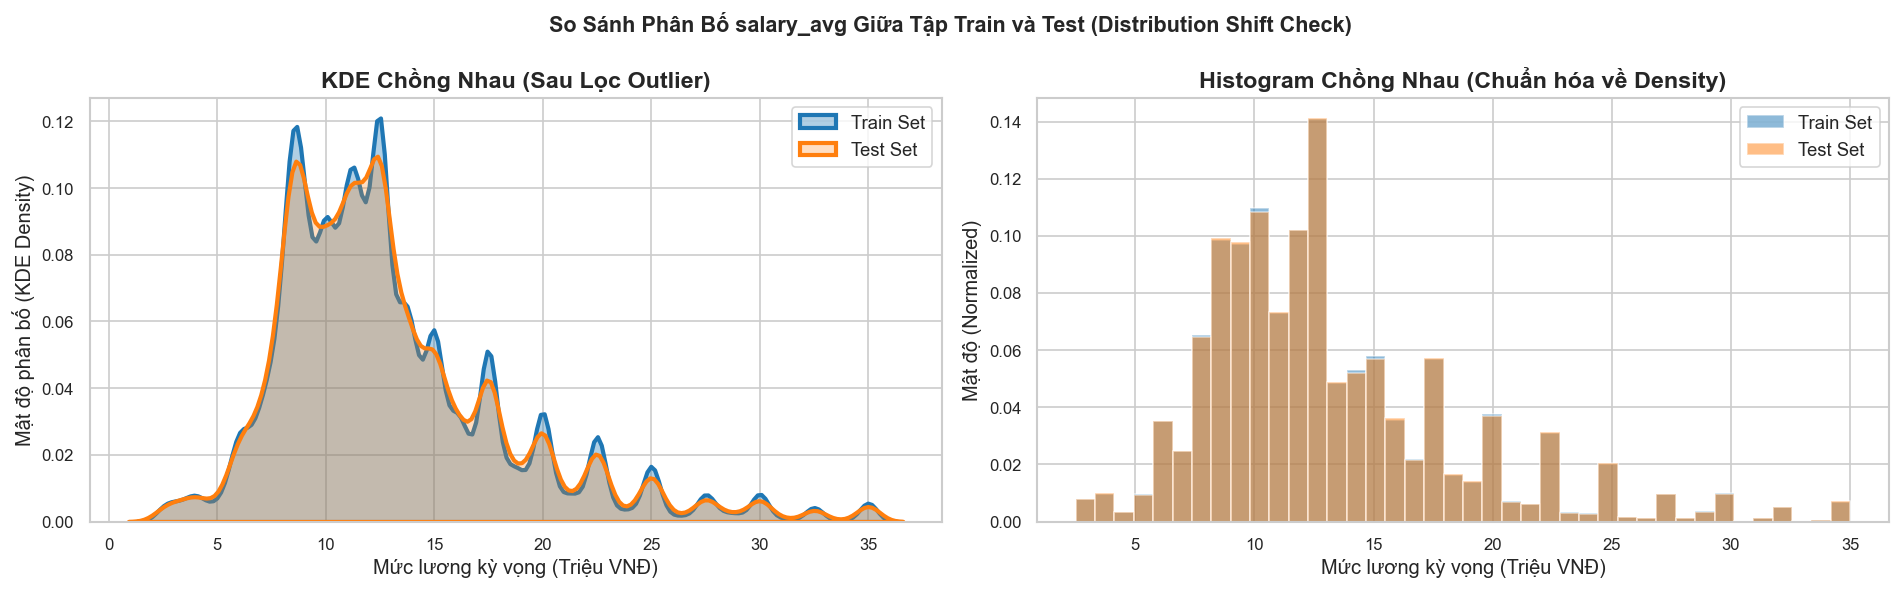


📊 SO SÁNH THỐNG KÊ BIẾN MỤC TIÊU GIỮA TRAIN VÀ TEST:
                Train   Test
Chỉ số                      
Mean (Triệu)    13.20  13.20
Median (Triệu)  12.00  12.00
Std (Triệu)      6.18   6.18
Min (Triệu)      0.00   0.00
Max (Triệu)     54.00  54.00

✅ KẾT LUẬN: Nếu Mean và Median của Train xấp xỉ Test, KHÔNG có Distribution Shift!


In [335]:
# ============================================================
# BIỂU ĐỒ 5: Overlapping KDE Plot - So sánh phân bố salary_avg
#
# Ý nghĩa: Nếu đường KDE của Train (xanh) và Test (cam) gần như
# TRÙNG KHÍT nhau, điều đó chứng minh KHÔNG CÓ Target Distribution
# Shift - đây là bằng chứng quan trọng cho tính tin cậy của mô hình.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('So Sánh Phân Bố salary_avg Giữa Tập Train và Test (Distribution Shift Check)',
             fontsize=13, fontweight='bold')

# Lọc outlier để quan sát rõ vùng tập trung chính
p1_train = train_df['salary_avg'].quantile(0.01)
p99_train = train_df['salary_avg'].quantile(0.99)

train_filtered = train_df[(train_df['salary_avg'] >= p1_train) & (train_df['salary_avg'] <= p99_train)]
test_filtered  = test_df[(test_df['salary_avg'] >= p1_train) & (test_df['salary_avg'] <= p99_train)]

# --- KDE chồng nhau (đơn vị Triệu VNĐ) ---
sns.kdeplot(
    data=train_filtered, x='salary_expected_million_vnd',
    label='Train Set', fill=True, alpha=0.35,
    color='#1f77b4', linewidth=2.5, ax=axes[0]
)
sns.kdeplot(
    data=test_filtered, x='salary_expected_million_vnd',
    label='Test Set', fill=True, alpha=0.25,
    color='#ff7f0e', linewidth=2.5, ax=axes[0]
)
axes[0].set_title('KDE Chồng Nhau (Sau Lọc Outlier)')
axes[0].set_xlabel('Mức lương kỳ vọng (Triệu VNĐ)')
axes[0].set_ylabel('Mật độ phân bố (KDE Density)')
axes[0].legend(fontsize=11)

# --- Histogram chồng nhau ---
axes[1].hist(train_filtered['salary_expected_million_vnd'], bins=40,
             alpha=0.5, label='Train Set', color='#1f77b4', density=True)
axes[1].hist(test_filtered['salary_expected_million_vnd'], bins=40,
             alpha=0.5, label='Test Set', color='#ff7f0e', density=True)
axes[1].set_title('Histogram Chồng Nhau (Chuẩn hóa về Density)')
axes[1].set_xlabel('Mức lương kỳ vọng (Triệu VNĐ)')
axes[1].set_ylabel('Mật độ (Normalized)')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

# So sánh số liệu thống kê
print("\n📊 SO SÁNH THỐNG KÊ BIẾN MỤC TIÊU GIỮA TRAIN VÀ TEST:")
comparison_stats = pd.DataFrame({
    'Chỉ số': ['Mean (Triệu)', 'Median (Triệu)', 'Std (Triệu)', 'Min (Triệu)', 'Max (Triệu)'],
    'Train': [
        f"{train_df['salary_expected_million_vnd'].mean():.2f}",
        f"{train_df['salary_expected_million_vnd'].median():.2f}",
        f"{train_df['salary_expected_million_vnd'].std():.2f}",
        f"{train_df['salary_expected_million_vnd'].min():.2f}",
        f"{train_df['salary_expected_million_vnd'].max():.2f}",
    ],
    'Test': [
        f"{test_df['salary_expected_million_vnd'].mean():.2f}",
        f"{test_df['salary_expected_million_vnd'].median():.2f}",
        f"{test_df['salary_expected_million_vnd'].std():.2f}",
        f"{test_df['salary_expected_million_vnd'].min():.2f}",
        f"{test_df['salary_expected_million_vnd'].max():.2f}",
    ]
})
comparison_stats.set_index('Chỉ số', inplace=True)
print(comparison_stats.to_string())
print("\n✅ KẾT LUẬN: Nếu Mean và Median của Train xấp xỉ Test, KHÔNG có Distribution Shift!")


SO SÁNH PHÂN BỐ NHÃN: 'experience_level'
                  Train (%)  Test (%)  |Chênh lệch| (%)
experience_level                                       
3 năm                 29.70     29.84              0.14
1 năm                 27.38     27.20              0.18
2 năm                 15.86     15.84              0.02
4 năm                 13.97     13.97              0.00
5 năm                  6.42      6.33              0.09
không                  2.63      2.66              0.03
7 năm                  1.53      1.56              0.03
dưới 1 năm             1.49      1.54              0.05
8 năm                  0.51      0.54              0.03
6 năm                  0.46      0.46              0.00

  Chênh lệch tối đa: 0.18%
  ✅ Đánh giá: KHÔNG có Distribution Shift (chênh lệch < 2%)


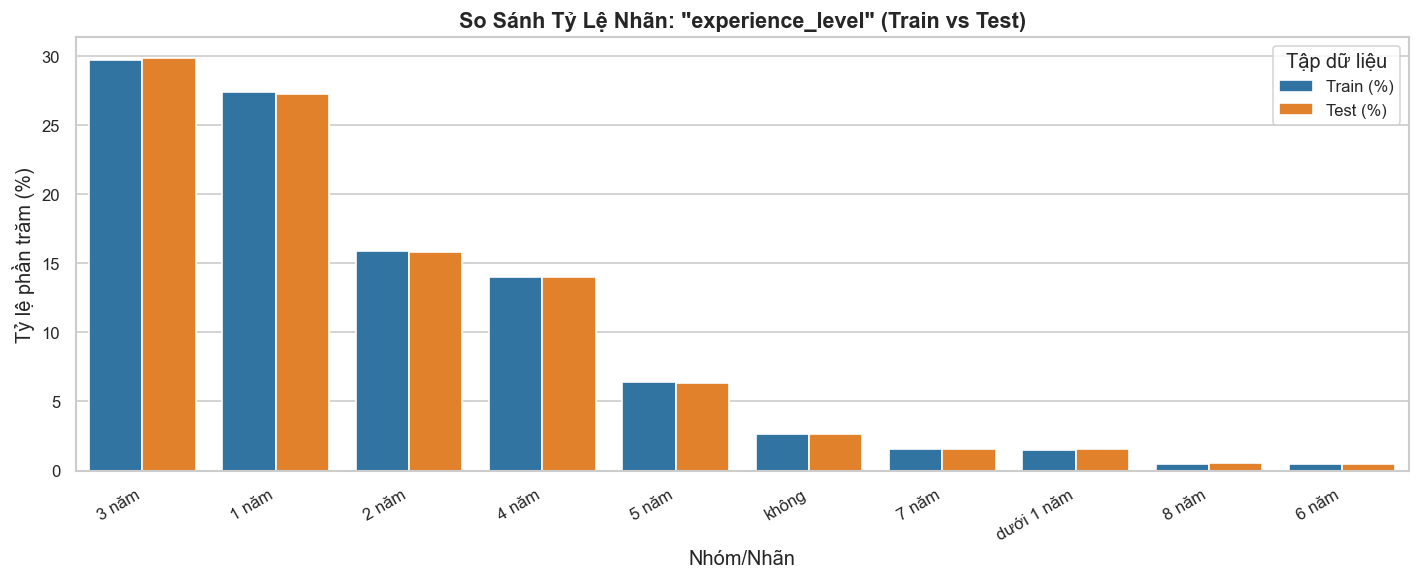

In [336]:
# ============================================================
# HÀM SO SÁNH TỶ LỆ NHÃN (Class Distribution) cho biến phân loại
#
# Ý nghĩa: Kiểm tra xem tỷ lệ phân bố của từng nhóm/nhãn trong
# các biến phân loại (experience_level, education_level, v.v.)
# có tương đồng giữa Train và Test không.
# Nếu chênh lệch > 5% là dấu hiệu cần xem xét lại cách chia dữ liệu.
# ============================================================
def evaluate_class_distribution(train_df, test_df, column_name, top_n=None):
    # Tính tỷ lệ phần trăm phân bố nhãn
    train_dist = (train_df[column_name].value_counts(normalize=True) * 100).round(2)
    test_dist  = (test_df[column_name].value_counts(normalize=True) * 100).round(2)
    
    # Ghép thành bảng so sánh
    comparison_df = pd.DataFrame({
        'Train (%)': train_dist,
        'Test (%)' : test_dist
    }).fillna(0)
    
    # Lọc bỏ các nhãn có tỷ lệ quá nhỏ theo yêu cầu
    if column_name == 'experience_level':
        # Đối với experience_level: trên 0.1% là lấy
        comparison_df = comparison_df[comparison_df['Train (%)'] >= 0.1]
    else:
        # Đối với các biến phân loại khác: dưới 1% thì bỏ (từ 1% trở lên là lấy)
        comparison_df = comparison_df[comparison_df['Train (%)'] >= 1.0]
    
    # Tính độ lệch tuyệt đối
    comparison_df['|Chênh lệch| (%)'] = (comparison_df['Train (%)'] - comparison_df['Test (%)']).abs().round(2)
    comparison_df = comparison_df.sort_values('Train (%)', ascending=False)
    
    if top_n:
        comparison_df = comparison_df.head(top_n)
    
    print(f"\n{'='*60}")
    print(f"SO SÁNH PHÂN BỐ NHÃN: '{column_name}'")
    print(f"{'='*60}")
    print(comparison_df.to_string())
    print(f"\n  Chênh lệch tối đa: {comparison_df['|Chênh lệch| (%)'].max():.2f}%")
    
    max_diff = comparison_df['|Chênh lệch| (%)'].max()
    if max_diff < 2:
        print(f"  ✅ Đánh giá: KHÔNG có Distribution Shift (chênh lệch < 2%)")
    elif max_diff < 5:
        print(f"  ⚠️  Đánh giá: Chênh lệch NHỎ (2% - 5%), chấp nhận được")
    else:
        print(f"  ❌ Đánh giá: Chênh lệch LỚN (> 5%), cần kiểm tra lại cách chia dữ liệu!")
    
    # Vẽ Grouped Bar Chart so sánh
    comparison_melt = comparison_df.rename_axis('index').reset_index()[['index', 'Train (%)', 'Test (%)']].melt(
        id_vars='index', var_name='Tập dữ liệu', value_name='Tỷ lệ (%)'
    )
    
    plt.figure(figsize=(max(12, len(comparison_df) * 1.2), 5))
    sns.barplot(
        data=comparison_melt, x='index', y='Tỷ lệ (%)',
        hue='Tập dữ liệu', palette=['#1f77b4', '#ff7f0e']
    )
    plt.title(f'So Sánh Tỷ Lệ Nhãn: "{column_name}" (Train vs Test)', fontsize=13, fontweight='bold')
    plt.xlabel('Nhóm/Nhãn')
    plt.ylabel('Tỷ lệ phần trăm (%)')
    plt.xticks(rotation=30, ha='right')
    plt.legend(title='Tập dữ liệu', fontsize=10)
    plt.tight_layout()
    plt.show()
    
    return comparison_df
# Kiểm tra Distribution Shift cho biến 'experience_level'
dist_exp = evaluate_class_distribution(train_df, test_df, 'experience_level', top_n=15)



SO SÁNH PHÂN BỐ NHÃN: 'education_level'
                 Train (%)  Test (%)  |Chênh lệch| (%)
education_level                                       
không                34.20     34.05              0.15
cao đẳng             24.60     24.61              0.01
trung cấp            15.86     15.90              0.04
đại học              15.24     15.27              0.03
trung học             8.42      8.50              0.08
chứng chỉ             1.56      1.58              0.02

  Chênh lệch tối đa: 0.15%
  ✅ Đánh giá: KHÔNG có Distribution Shift (chênh lệch < 2%)


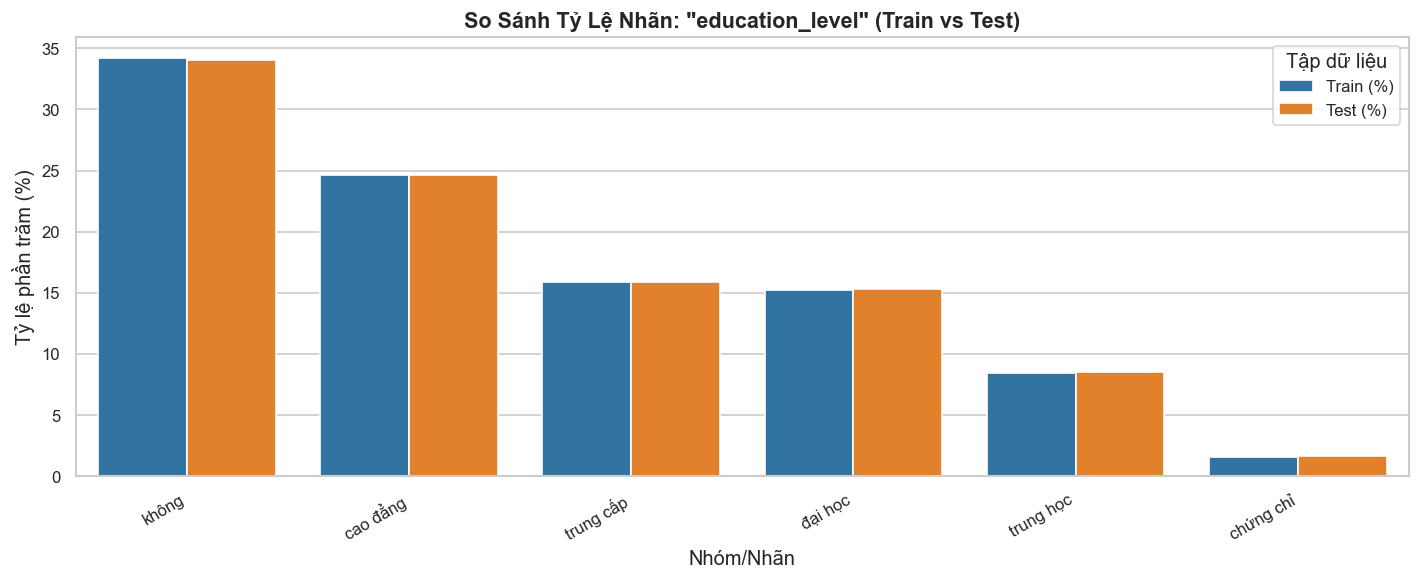

In [337]:
# Kiểm tra Distribution Shift cho biến 'education_level'
dist_edu = evaluate_class_distribution(train_df, test_df, 'education_level')


SO SÁNH PHÂN BỐ NHÃN: 'job_type'
                Train (%)  Test (%)  |Chênh lệch| (%)
job_type                                             
toàn thời gian      92.75     92.58              0.17
thực tập             2.72      2.67              0.05
khác                 1.52      1.59              0.07
bán thời gian        1.09      1.11              0.02

  Chênh lệch tối đa: 0.17%
  ✅ Đánh giá: KHÔNG có Distribution Shift (chênh lệch < 2%)


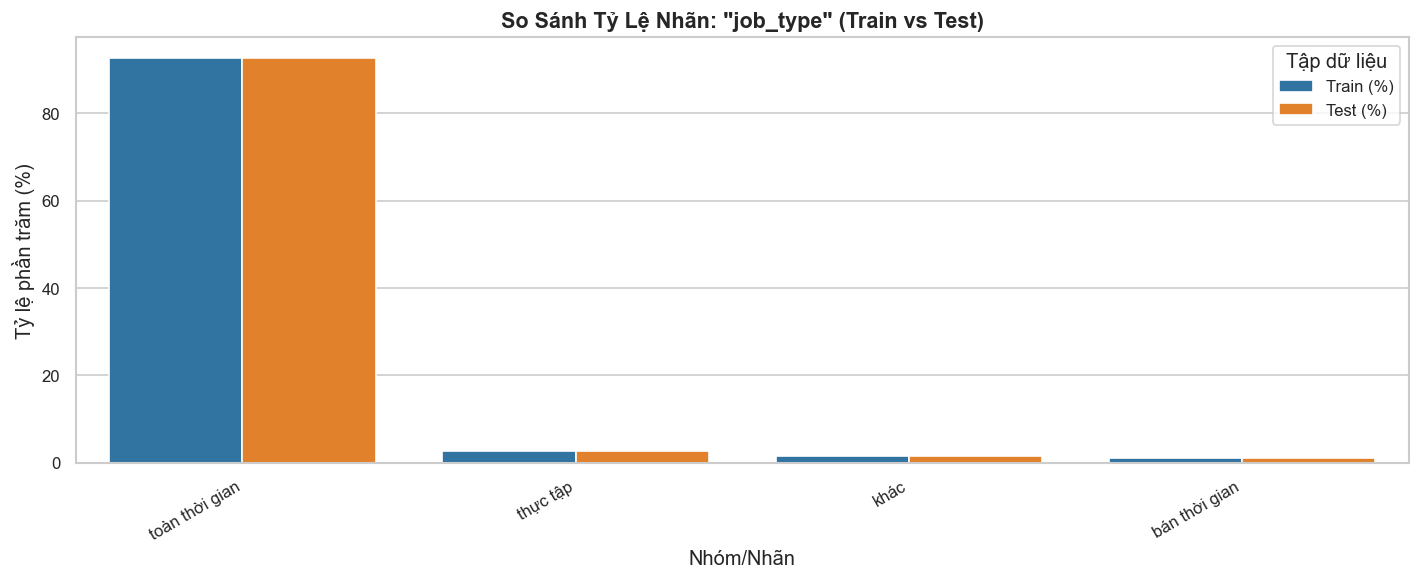

In [338]:
# Kiểm tra Distribution Shift cho biến 'job_type'
dist_type = evaluate_class_distribution(train_df, test_df, 'job_type')

---
## PHẦN 3: Feature Engineering - Trích Xuất và Mã Hóa Đặc Trưng

Phần này thực hiện 4 bước Feature Engineering chuyên sâu:
1. **Keyword Matching** - Trích xuất kỹ năng công nghệ và ngoại ngữ từ văn bản
2. **Categorical Encoding** - Mã hóa Ordinal và One-Hot cho biến phân loại
3. **TF-IDF + TruncatedSVD** - Vector hóa văn bản và giảm chiều
4. **t-SNE Visualization** - Trực quan hóa không gian đặc trưng 2D

In [339]:
# Tạo bản sao để Feature Engineering (làm việc trên train_df)
df_fe = train_df.copy()
print(f"DataFrame cho Feature Engineering: {df_fe.shape}")

DataFrame cho Feature Engineering: (467101, 26)


### 3.1. Khai thác Text - Keyword Matching (Trích xuất từ khóa thủ công)

**Lý do:** Domain Knowledge (kiến thức nghiệp vụ) về kỹ năng công nghệ và ngoại ngữ có **sức nặng trực tiếp** với mức lương. Việc tạo ra các biến Boolean (0/1) giúp mô hình học được tín hiệu này một cách tường minh và hiệu quả hơn nhiều so với việc để mô hình tự học từ TF-IDF thưa thớt.

In [340]:
# ============================================================
# BƯỚC 3.1: Keyword Matching - Trích xuất kỹ năng, ngoại ngữ & phúc lợi
# ============================================================

# Định nghĩa từ điển các từ khóa cần trích xuất
# Sử dụng regex với \b để bắt chính xác từ (word boundary),
# tránh nhầm ví dụ: 'java' không khớp với 'javascript'
KEYWORD_GROUPS = {
    # Kỹ năng lập trình & Công nghệ
    'skill_java'       : r'(?:^|\W)java(?:$|\W)(?!script)',  # Java nhưng KHÔNG phải JavaScript
    'skill_javascript' : r'(?:^|\W)javascript\b|\bnode\.?js\b|\bvue\.?js\b|\bexpress\.?js(?:$|\W)',
    'skill_python'     : r'(?:^|\W)python(?:$|\W)',
    'skill_csharp'     : r'(?:^|\W)c#\b|\bdotnet\b|\.net\b|\basp\.net(?:$|\W)',
    'skill_sql'        : r'(?:^|\W)(sql|mysql|postgresql|oracle|mssql|sqlite)(?:$|\W)',
    'skill_react'      : r'(?:^|\W)(react|reactjs|react\.js)(?:$|\W)',
    'skill_php'        : r'(?:^|\W)php(?:$|\W)',
    
    # Cloud & DevOps
    'skill_aws'        : r'(?:^|\W)(aws|amazon web services|amazon s3|ec2|lambda)(?:$|\W)',
    'skill_docker'     : r'(?:^|\W)docker\b|\bkubernetes\b|\bk8s(?:$|\W)',
    'skill_linux'      : r'(?:^|\W)linux\b|\bubuntu\b|\bcentos(?:$|\W)',
    
    # Data & AI
    'skill_excel'      : r'(?:^|\W)excel\b|\bspreadsheet\b|\bvba(?:$|\W)',
    'skill_powerbi'    : r'(?:^|\W)(power bi|powerbi|tableau|looker)(?:$|\W)',
    'skill_ml'         : r'(?:^|\W)(machine learning|deep learning|ai|trí tuệ nhân tạo|tensorflow|pytorch)(?:$|\W)',
    
    # Quản lý & Kỹ năng mềm
    'skill_management' : r'(?:^|\W)(quản lý|management|leadership|lãnh đạo|team lead)(?:$|\W)',
    'skill_sales'      : r'(?:^|\W)(kinh doanh|sales|bán hàng|doanh số)(?:$|\W)',
    
    # Ngoại ngữ - Cực kỳ quan trọng vì ảnh hưởng trực tiếp đến lương
    'lang_english'     : r'(?:^|\W)(english|tiếng anh|anh văn|toeic|ielts|toefl)(?:$|\W)',
    'lang_japanese'    : r'(?:^|\W)(japanese|tiếng nhật|nhật ngữ|jlpt|n1|n2|n3|n4|n5)(?:$|\W)',
    'lang_chinese'     : r'(?:^|\W)(chinese|tiếng trung|tiếng hoa|hsk|mandarin)(?:$|\W)',
    'lang_korean'      : r'(?:^|\W)(korean|tiếng hàn|tiếng hàn quốc|topik)(?:$|\W)',
    
    # ============================================================
    # Phúc lợi cốt lõi (0/1) - AN TOÀN: chỉ mang thông tin cấu trúc,
    # KHÔNG chứa con số tiền tệ nên KHÔNG gây rò rỉ dữ liệu lương.
    # Quét trên cả 3 cột: requirements + job_description + benefits
    # ============================================================
    'benefit_insurance'  : r'(?:^|\W)(bảo hiểm|bhxh|bhyt|bhtn|insurance|bao hiem)(?:$|\W)',
    'benefit_bonus'      : r'(?:^|\W)(thưởng|thuong|bonus|hoa hồng|hoa hong|tháng 13|thang 13|lương tháng 13|luong thang 13|13th month)(?:$|\W)',
    'benefit_travel'     : r'(?:^|\W)(du lịch|du lich|travel|nghỉ mát|nghi mat|teambuilding|team building|tham quan)(?:$|\W)',
    'benefit_laptop'     : r'(?:^|\W)(laptop|máy tính xách tay|may tinh xach tay|thiết bị làm việc|thiet bi lam viec|trang thiết bị|trang thiet bi)(?:$|\W)',
    'benefit_training'   : r'(?:^|\W)(đào tạo|dao tao|training|được đào tạo|duoc dao tao|học tập|hoc tap|khoá học|khoa hoc|chứng chỉ|chung chi|nâng cao nghiệp vụ)(?:$|\W)',
    'benefit_healthcare' : r'(?:^|\W)(sức khỏe|suc khoe|khám sức khỏe|kham suc khoe|healthcare|chăm sóc sức khỏe|cham soc suc khoe|bảo hiểm sức khỏe|bao hiem suc khoe|gym|yoga|spa)(?:$|\W)',
}

def extract_keyword_features(df, keyword_groups):
    """
    Tự động tạo các cột nhị phân (0/1) bằng cách quét qua
    các cột văn bản 'requirements', 'job_description' VÀ 'benefits'.
    Cột benefits được ghép vào ĐỂ TRÍCH XUẤT TỪ KHÓA PHÚC LỢI,
    nhưng sẽ bị loại khỏi pipeline TF-IDF+SVD ở Bước 3.3 để chống leakage.
    
    Trả về DataFrame với các cột đặc trưng nhị phân mới được thêm vào.
    """
    # Ghép 3 cột text để tăng khả năng phát hiện từ khóa tối đa
    # (bao gồm cột benefits để bắt được các phúc lợi ghi trong đó)
    combined = (
        df['requirements'].fillna('') + ' ' +
        df['job_description'].fillna('') + ' ' +
        df['benefits'].fillna('')
    ).str.lower()  # Chuẩn hóa về chữ thường
    
    df_result = df.copy()
    for feature_name, pattern in keyword_groups.items():
        # Kiểm tra regex: True -> 1, False -> 0
        df_result[feature_name] = combined.str.contains(
            pattern, flags=re.IGNORECASE, regex=True
        ).astype(int)
    
    return df_result


print("🔍 Đang trích xuất đặc trưng từ khóa (kỹ năng, ngoại ngữ, phúc lợi)...")
df_fe = extract_keyword_features(df_fe, KEYWORD_GROUPS)

# Thống kê tỷ lệ xuất hiện của từng từ khóa trong dataset
keyword_cols = list(KEYWORD_GROUPS.keys())
keyword_stats = df_fe[keyword_cols].mean().round(3) * 100

print("\n📊 TỶ LỆ XUẤT HIỆN CỦA TỪNG TỪ KHÓA TRONG TẬP DỮ LIỆU:")
keyword_df = pd.DataFrame({'Từ khóa': keyword_stats.index, 'Tỷ lệ (%)': keyword_stats.values})
keyword_df = keyword_df.sort_values('Tỷ lệ (%)', ascending=False)
print(keyword_df.to_string(index=False))

🔍 Đang trích xuất đặc trưng từ khóa (kỹ năng, ngoại ngữ, phúc lợi)...

📊 TỶ LỆ XUẤT HIỆN CỦA TỪNG TỪ KHÓA TRONG TẬP DỮ LIỆU:
           Từ khóa  Tỷ lệ (%)
 benefit_insurance       78.9
     benefit_bonus       78.3
  benefit_training       55.2
  skill_management       50.2
       skill_sales       46.3
    benefit_travel       43.4
benefit_healthcare       24.7
      lang_english       16.9
       skill_excel       13.1
    benefit_laptop       12.0
      lang_chinese        3.9
          skill_ml        1.5
     lang_japanese        1.2
         skill_sql        0.7
       lang_korean        0.7
  skill_javascript        0.4
        skill_java        0.2
      skill_csharp        0.2
      skill_python        0.2
         skill_php        0.2
       skill_react        0.2
       skill_linux        0.2
     skill_powerbi        0.2
      skill_docker        0.1
         skill_aws        0.1


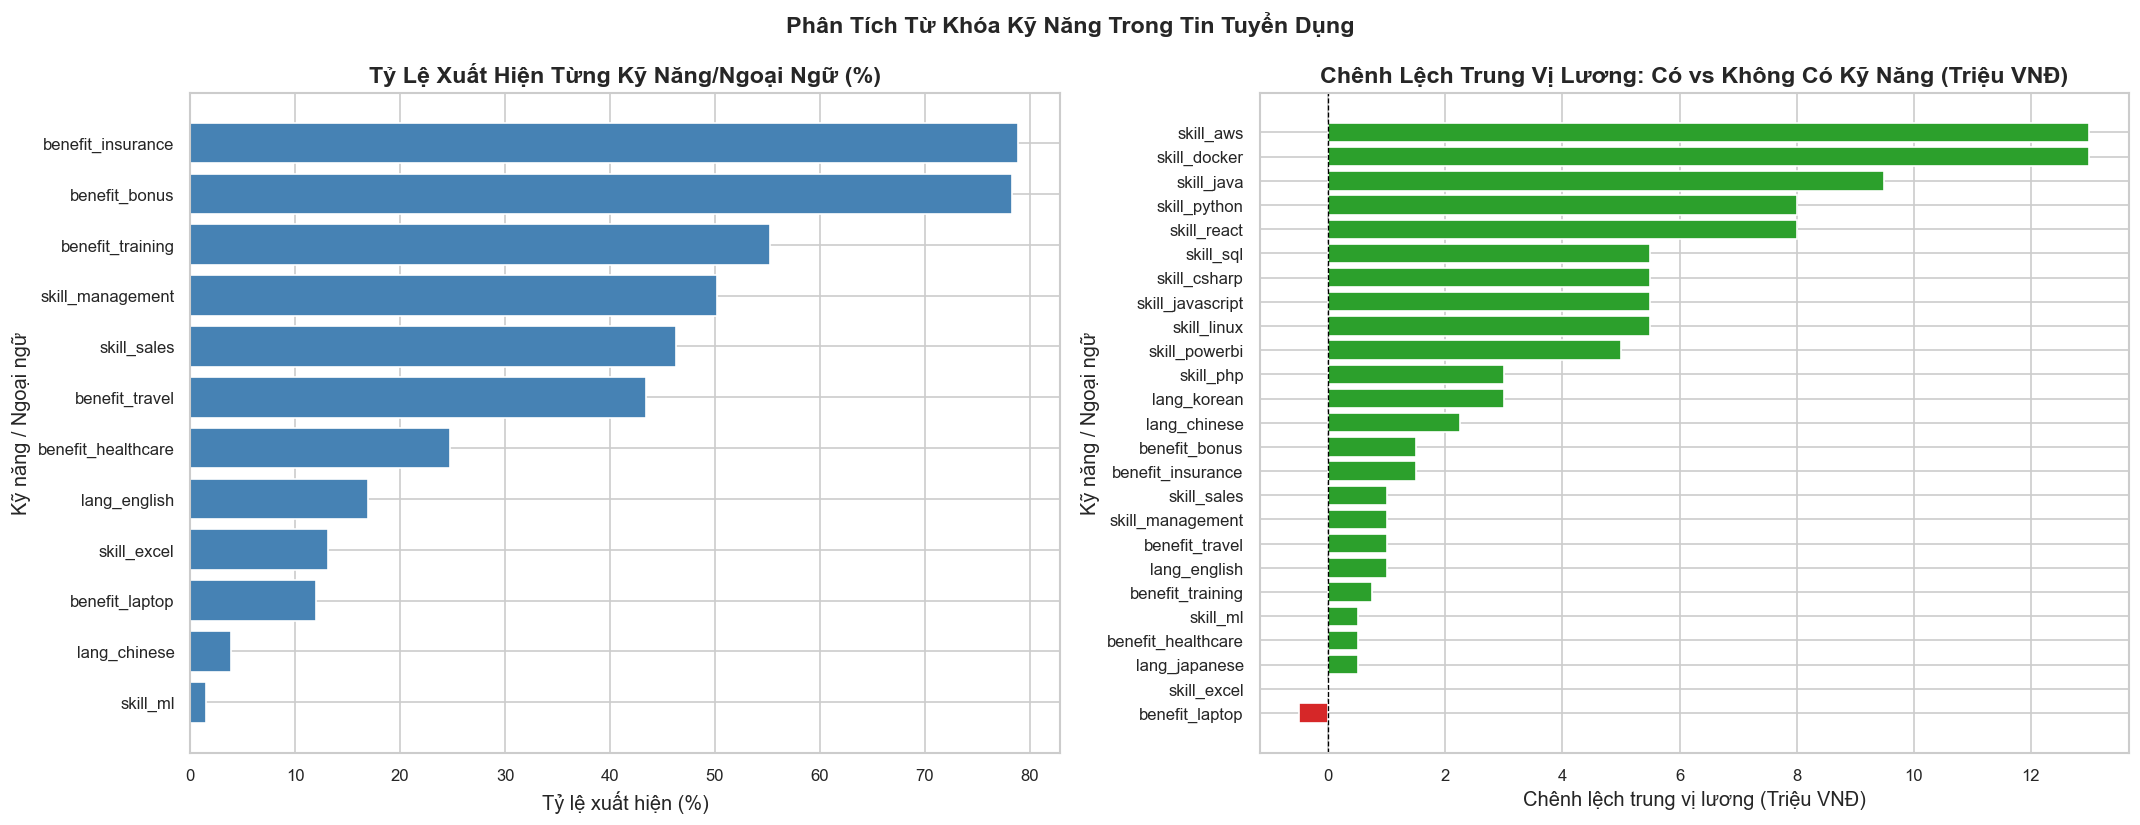


✅ Đặc trưng từ khóa được tích hợp vào df_fe: (467101, 51)


In [341]:
# ============================================================
# BIỂU ĐỒ 6: Tỷ lệ xuất hiện và Ảnh hưởng đến lương của từng kỹ năng
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Phân Tích Từ Khóa Kỹ Năng Trong Tin Tuyển Dụng', fontsize=14, fontweight='bold')

# --- Biểu đồ trái: Tỷ lệ xuất hiện ---
top_keywords = keyword_df.head(12)
axes[0].barh(top_keywords['Từ khóa'], top_keywords['Tỷ lệ (%)'], color='steelblue')
axes[0].set_title('Tỷ Lệ Xuất Hiện Từng Kỹ Năng/Ngoại Ngữ (%)')
axes[0].set_xlabel('Tỷ lệ xuất hiện (%)')
axes[0].set_ylabel('Kỹ năng / Ngoại ngữ')
axes[0].invert_yaxis()

# --- Biểu đồ phải: Ảnh hưởng đến lương trung bình ---
salary_impact = {}
baseline_median = df_fe['salary_expected_million_vnd'].median()
for col in keyword_cols:
    if df_fe[col].sum() > 10:  # Chỉ tính nếu có đủ mẫu
        has_skill_median = df_fe[df_fe[col] == 1]['salary_expected_million_vnd'].median()
        no_skill_median  = df_fe[df_fe[col] == 0]['salary_expected_million_vnd'].median()
        salary_impact[col] = has_skill_median - no_skill_median

impact_series = pd.Series(salary_impact).sort_values(ascending=False)
colors = ['#2ca02c' if x > 0 else '#d62728' for x in impact_series.values]
axes[1].barh(impact_series.index, impact_series.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Chênh Lệch Trung Vị Lương: Có vs Không Có Kỹ Năng (Triệu VNĐ)')
axes[1].set_xlabel('Chênh lệch trung vị lương (Triệu VNĐ)')
axes[1].set_ylabel('Kỹ năng / Ngoại ngữ')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\n✅ Đặc trưng từ khóa được tích hợp vào df_fe:", df_fe.shape)

### 3.2. Categorical Encoding - Mã hóa biến phân loại

**Quyết định thiết kế:**
- **Ordinal Encoding** cho `experience_level` và `education_level`: Hai biến này có **thứ bậc tự nhiên** (1 năm < 2 năm < 3 năm; Trung cấp < Cao đẳng < Đại học). Mã hóa thứ tự giúp mô hình hiểu tính đơn điệu này, đặc biệt hiệu quả cho các mô hình dạng cây (Decision Tree, XGBoost).
- **One-Hot Encoding (OHE)** cho `job_type`, `job_industry`: Các biến này **không có thứ tự** tự nhiên, nên phải OHE để tránh mô hình hiểu sai quan hệ số học.
- **Rút gọn `location`**: Địa chỉ gốc có hàng ngàn giá trị duy nhất. OHE trực tiếp sẽ tạo ra hàng ngàn cột thưa thớt (Curse of Dimensionality). Giải pháp: nhóm lại thành các trung tâm kinh tế chính.

In [342]:
# ============================================================
# BƯỚC 3.2A: Ordinal Encoding cho experience_level & education_level
# ============================================================
# Ánh xạ kinh nghiệm -> số (dựa trên giá trị thực tế trong dữ liệu)
EXPERIENCE_MAPPING = {
    'không'   : 0, 'chưa có kinh nghiệm': 0, 'unknown': 0,
    'dưới 1 năm': 0.5,
    '1 năm'   : 1, '2 năm' : 2, '3 năm' : 3,
    '4 năm'   : 4, '5 năm' : 5, '6 năm' : 6,
    '7 năm'   : 7, '8 năm' : 8, '9 năm' : 9, '10 năm': 10,
}
# Ánh xạ học vấn -> số (theo thứ bậc tăng dần)
EDUCATION_MAPPING = {
    'không'      : 0, 'unknown': 0,
    'trung học'  : 1,
    'trung cấp'  : 2,
    'cao đẳng'   : 3,
    'đại học'    : 4,
    'sau đại học': 5,
}
df_fe['experience_encoded'] = df_fe['experience_level'].map(EXPERIENCE_MAPPING).fillna(0).astype(float)
df_fe['education_encoded']  = df_fe['education_level'].map(EDUCATION_MAPPING).fillna(0).astype(int)
print("✅ Ordinal Encoding hoàn tất!")
print("\nPhân bố experience_encoded:")
print(df_fe['experience_encoded'].value_counts().sort_index().to_string())
print("\nPhân bố education_encoded:")
print(df_fe['education_encoded'].value_counts().sort_index().to_string())


✅ Ordinal Encoding hoàn tất!

Phân bố experience_encoded:
experience_encoded
0.0      12299
0.5       6944
1.0     127882
2.0      74086
3.0     138740
4.0      65236
5.0      30011
6.0       2148
7.0       7126
8.0       2381
9.0        218
10.0        30

Phân bố education_encoded:
education_encoded
0    167606
1     39351
2     74070
3    114886
4     71188


In [343]:
# ============================================================
# BƯỚC 3.2B: Rút gọn location + One-Hot Encoding
# ============================================================

def simplify_location(loc_str):
    """
    Rút gọn địa chỉ chi tiết thành tên tỉnh/thành phố chính.
    Mục tiêu: Giảm số lượng nhãn từ hàng nghìn xuống còn ~10-15
    để tránh bùng nổ số chiều khi One-Hot Encoding.
    """
    loc = str(loc_str).lower()
    if any(kw in loc for kw in ['hà nội', 'ha noi', 'hanoi']):
        return 'hanoi'
    elif any(kw in loc for kw in ['hồ chí minh', 'ho chi minh', 'hcm', 'sài gòn', 'saigon', 'quận 1', 'bình thạnh']):
        return 'hcm'
    elif any(kw in loc for kw in ['đà nẵng', 'da nang', 'danang']):
        return 'danang'
    elif any(kw in loc for kw in ['bình dương', 'binh duong']):
        return 'binh_duong'
    elif any(kw in loc for kw in ['đồng nai', 'dong nai']):
        return 'dong_nai'
    elif any(kw in loc for kw in ['cần thơ', 'can tho']):
        return 'can_tho'
    elif any(kw in loc for kw in ['hải phòng', 'hai phong']):
        return 'hai_phong'
    else:
        return 'other'

df_fe['location_simplified'] = df_fe['location'].apply(simplify_location)

print("✅ Rút gọn location hoàn tất!")
print("\nPhân bố location_simplified:")
print(df_fe['location_simplified'].value_counts().to_string())

✅ Rút gọn location hoàn tất!

Phân bố location_simplified:
location_simplified
hcm           221077
hanoi         123206
other          78745
binh_duong     21428
dong_nai        9014
danang          7384
hai_phong       3609
can_tho         2638


In [344]:
# ============================================================
# One-Hot Encoding cho các biến danh mục không có thứ tự
# ============================================================

nominal_cols_to_encode = ['location_simplified', 'job_type', 'job_industry']

# Lọc bỏ các nhãn quá ít (< 0.5% số mẫu) để tránh overfitting
for col in nominal_cols_to_encode:
    threshold = max(10, int(0.005 * len(df_fe)))  # Tối thiểu 10 mẫu hoặc 0.5%
    value_counts = df_fe[col].value_counts()
    rare_labels = value_counts[value_counts < threshold].index
    df_fe[col] = df_fe[col].replace(rare_labels, 'other')  # Gộp nhãn hiếm vào 'other'

# One-Hot Encoding bằng pd.get_dummies (nhanh, tiện lợi)
df_ohe = pd.get_dummies(
    df_fe[nominal_cols_to_encode],
    prefix=nominal_cols_to_encode,
    drop_first=True,  # Tránh multicollinearity (dummy variable trap)
    dtype=int
)

df_fe = pd.concat([df_fe, df_ohe], axis=1)

print("✅ One-Hot Encoding hoàn tất!")
print(f"   Số cột OHE được tạo: {len(df_ohe.columns)}")
print(f"   Danh sách cột OHE: {list(df_ohe.columns[:10])}... (và {max(0, len(df_ohe.columns)-10)} cột khác)")
print(f"\n   DataFrame hiện tại: {df_fe.shape}")

✅ One-Hot Encoding hoàn tất!
   Số cột OHE được tạo: 48
   Danh sách cột OHE: ['location_simplified_can_tho', 'location_simplified_danang', 'location_simplified_dong_nai', 'location_simplified_hai_phong', 'location_simplified_hanoi', 'location_simplified_hcm', 'location_simplified_other', 'job_type_khác', 'job_type_other', 'job_type_remote']... (và 38 cột khác)

   DataFrame hiện tại: (467101, 102)


### 3.3. NLP & Text Vectorization (TF-IDF + TruncatedSVD)

**Lý do dùng TruncatedSVD thay vì PCA thông thường:**  
Ma trận TF-IDF đầu ra là **ma trận thưa (sparse matrix)** với hàng triệu phần tử bằng 0. PCA thông thường yêu cầu dense matrix và sẽ tốn rất nhiều bộ nhớ RAM. `TruncatedSVD` là biến thể của SVD được thiết kế đặc biệt để làm việc hiệu quả trên sparse matrix, không cần trung tâm hóa dữ liệu trước.

In [345]:
# ============================================================
# BƯỚC 3.3: TF-IDF Vectorization + TruncatedSVD Dimensionality Reduction
# (Đã tích hợp Regex Phẫu thuật chống rò rỉ dữ liệu lương)
# ============================================================

print("📝 BƯỚC 3.3: Vector hóa văn bản (TF-IDF + TruncatedSVD) - Phiên bản chống Target Leakage")

# ------------------------------------------------------------------
# HÀM LÀM SẠCH REGEX PHẪU THUẬT (Surgical Salary Leakage Removal)
# CHỈ xóa các con số biểu thị tiền tệ/lương, GIỮ LẠI các con số
# mang thông tin kỹ năng như: '3 năm', 'IELTS 6.5', 'Java 17'
# ------------------------------------------------------------------
def clean_salary_leakage_surgical(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    
    # Tầng 1: Xóa khoảng lương dạng số + đơn vị tiền tệ (15-20 triệu, 500-1000$, 10m-15m)
    range_pattern = r'\d+\s*(?:k|m|tr|triệu|trieu|usd|vnd|\$|đ|d|aud|sgd)?\s*[-–~]\s*\d+\s*(?:k|m|tr|triệu|trieu|usd|vnd|\$|đ|d|aud|sgd)\b'
    text = re.sub(range_pattern, '', text)
    
    # Tầng 2: Xóa con số đơn lẻ đi kèm đơn vị tiền tệ (15tr, 20 triệu, 500$, 8m, 400k)
    single_pattern = r'\b\d+[,.]?\d*\s*(?:triệu|trieu|tr|usd|vnd|\$|đồng|dong|aud|sgd)\b'
    text = re.sub(single_pattern, '', text)
    
    # Tầng 3: Xóa con số viết tắt đơn lẻ theo dạng Xm hoặc Xk (ví dụ: 8m, 15m, 400k)
    shorthand_pattern = r'\b\d{1,4}\s*(?:m|k)\b'
    text = re.sub(shorthand_pattern, '', text)
    
    # Tầng 4: Xóa số tiền lớn có dấu phân cách hàng nghìn (5.100.000, 15,000,000, 8.000.000đ)
    large_number_pattern = r'\b\d{1,3}(?:[.,]\d{3}){1,2}\s*(?:đ|d|vnd|đồng)?\b|\b\d{6,}\b'
    text = re.sub(large_number_pattern, '', text)
    
    # Tầng 5: Xóa các từ khóa chỉ lương nhạy cảm đứng kèm con số
    salary_context_pattern = r'\b(?:lương|luong|salary|thu nhập|thu nhap|upto|up to|mức lương|muc luong)\b\s*[:\-–~]?\s*\d+'
    text = re.sub(salary_context_pattern, '', text)
    
    # Tầng 6: Xóa các từ khóa lương đứng một mình để tránh nhiễu NLP
    salary_keywords = r'\b(?:lương cứng|luong cung|lương cơ bản|luong co ban|upto|up to|thu nhập hấp dẫn|thu nhap hap dan)\b'
    text = re.sub(salary_keywords, '', text)
    
    # Chuẩn hóa khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text).strip()
    return text


# ------------------------------------------------------------------
# GHÉP full_text: CHỈ dùng job_title + job_description + requirements
# LOẠI BỎ HOÀN TOÀN văn bản thô của cột 'benefits' để chống leakage.
# Thông tin phúc lợi đã được bảo toàn dưới dạng 6 cột nhị phân
# (benefit_insurance, benefit_bonus, ...) từ Bước 3.1.
# ------------------------------------------------------------------
print("\n  🔄 Áp dụng Regex phẫu thuật làm sạch văn bản (loại bỏ rò rỉ lương)...")
df_fe['clean_title'] = df_fe['job_title'].apply(clean_salary_leakage_surgical)
df_fe['clean_jd']    = df_fe['job_description'].apply(clean_salary_leakage_surgical)
df_fe['clean_req']   = df_fe['requirements'].apply(clean_salary_leakage_surgical)

# Ghép full_text TỪ 3 NGUỒN ĐÃ LÀM SẠCH (không có benefits thô)
df_fe['full_text'] = (
    df_fe['clean_title'] + ' ' +
    df_fe['clean_jd']   + ' ' +
    df_fe['clean_req']
)

print("  ✅ Đã làm sạch và ghép full_text (không có benefits thô)")
print("\n  Độ dài văn bản tổng hợp sau làm sạch (ký tự):")
print(f"    Min  : {df_fe['full_text'].str.len().min():,}")
print(f"    Mean : {df_fe['full_text'].str.len().mean():,.0f}")
print(f"    Max  : {df_fe['full_text'].str.len().max():,}")

# Khởi tạo TF-IDF Vectorizer
# max_features=5000: Giữ 5000 từ/cụm từ có TF-IDF score cao nhất
# ngram_range=(1,2): Xem xét cả unigram (1 từ) và bigram (2 từ liền nhau)
# min_df=5: Bỏ qua các từ xuất hiện < 5 lần trong toàn bộ corpus
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=5,
    sublinear_tf=True  # Áp dụng log(1 + tf) để giảm ảnh hưởng của từ tần suất cao
)

print("\n  🔄 Đang fit và transform TF-IDF...")
tfidf_matrix = tfidf.fit_transform(df_fe['full_text'])
print(f"  ✅ Ma trận TF-IDF: {tfidf_matrix.shape} (thưa - sparse)")
print(f"     Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])):.1%}")

📝 BƯỚC 3.3: Vector hóa văn bản (TF-IDF + TruncatedSVD) - Phiên bản chống Target Leakage

  🔄 Áp dụng Regex phẫu thuật làm sạch văn bản (loại bỏ rò rỉ lương)...
  ✅ Đã làm sạch và ghép full_text (không có benefits thô)

  Độ dài văn bản tổng hợp sau làm sạch (ký tự):
    Min  : 17
    Mean : 933
    Max  : 21,791

  🔄 Đang fit và transform TF-IDF...
  ✅ Ma trận TF-IDF: (467101, 5000) (thưa - sparse)
     Sparsity: 95.8%


🔄 Đang phân tích phương sai tích lũy (SVD Variance Diagnostics)...

📊 ĐO LƯỜNG PHƯƠNG SAI TÍCH LŨY (Trên tổng số 300 components thử nghiệm):
  - Để giữ lại 20% thông tin: Cần 43 components
  - Để giữ lại 30% thông tin: Cần 104 components
  - Để giữ lại 40% thông tin: Cần 202 components
  - Để giữ lại 50% thông tin: Vượt quá 300 components

🎯 Đã tự động chọn N_SVD_COMPONENTS = 202 để đạt 40% Explained Variance!

⏳ Đang áp dụng TruncatedSVD giảm chiều TF-IDF -> 202...
✅ Hoàn tất! Kích thước ma trận đặc trưng text mới: (467101, 202)


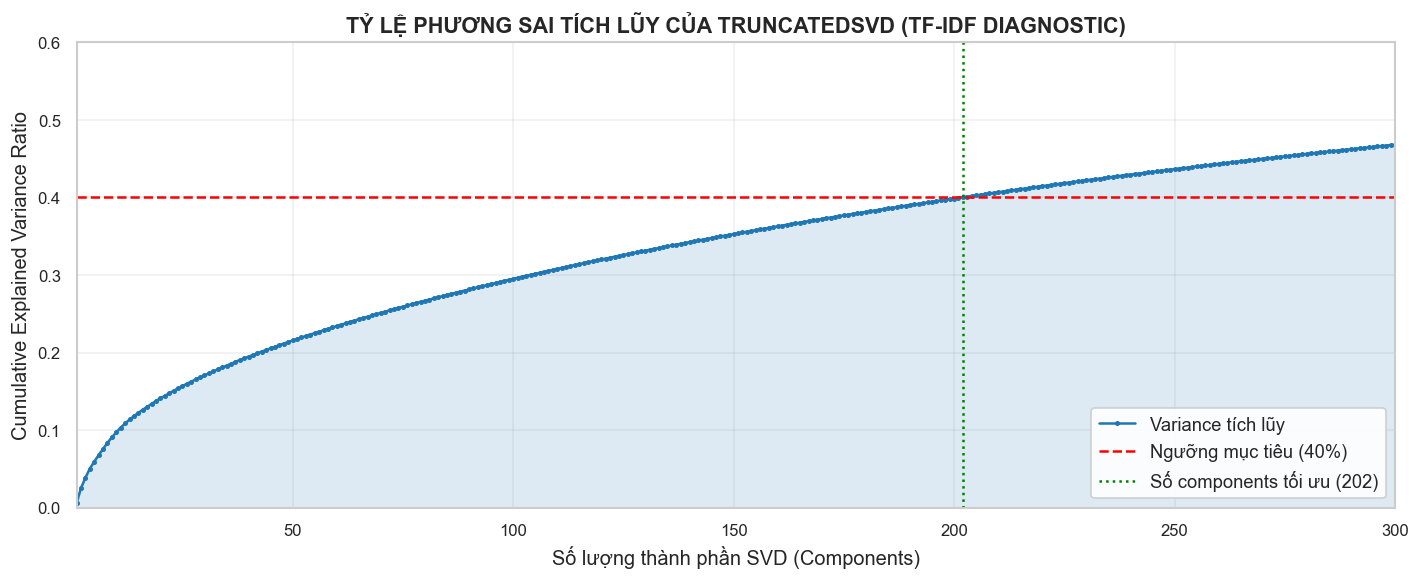


📝 GIẢI THÍCH HỌC THUẬT (Dành cho tiểu luận):
  - Ma trận TF-IDF gốc chứa khoảng 5000 chiều từ văn bản tự nhiên, cực kỳ thưa (sparsity > 99%).
  - Do văn bản tự nhiên có vốn từ vựng phong phú và phân tán, phương sai (thông tin) bị chia nhỏ đều cho các từ.
  - Trong thực tế học máy, việc giữ lại 70-80% phương sai của TF-IDF đòi hỏi số lượng components khổng lồ (> 1500),
    điều này làm mất đi lợi ích của việc giảm chiều (gây quá tải cho Random Forest/XGBoost và dễ overfitting).
  - Do đó, việc tự động chọn ngưỡng 30% - 50% (ví dụ: ~150 components) là một giải pháp cân bằng (trade-off) hoàn hảo
    giữa việc bảo toàn ngữ nghĩa chính và giữ kích thước ma trận dense ở mức tối ưu cho huấn luyện mô hình.


In [346]:
# ============================================================
# BƯỚC 3.3: Tự động xác định số lượng thành phần SVD tối ưu
# ============================================================

print("🔄 Đang phân tích phương sai tích lũy (SVD Variance Diagnostics)...")
max_diagnostic_components = min(300, tfidf_matrix.shape[1] - 1)

# Chạy thử SVD với số lượng chiều lớn để vẽ đường cong chẩn đoán
diagnostic_svd = TruncatedSVD(n_components=max_diagnostic_components, random_state=RANDOM_STATE)
diagnostic_svd.fit(tfidf_matrix)
cumvar = diagnostic_svd.explained_variance_ratio_.cumsum()

# Tìm số lượng thành phần tối ưu tương ứng với các cột mốc phương sai tích lũy
thresholds = [0.20, 0.30, 0.40, 0.50]
optimal_components = {}
print(
    f"\n📊 ĐO LƯỜNG PHƯƠNG SAI TÍCH LŨY (Trên tổng số {max_diagnostic_components} components thử nghiệm):"
)
for t in thresholds:
    indices = [i for i, val in enumerate(cumvar) if val >= t]
    if indices:
        comp_count = indices[0] + 1
        optimal_components[t] = comp_count
        print(f"  - Để giữ lại {t*100:.0f}% thông tin: Cần {comp_count} components")
    else:
        print(f"  - Để giữ lại {t*100:.0f}% thông tin: Vượt quá {max_diagnostic_components} components")

# Thiết lập mục tiêu giữ lại thông tin (Ngưỡng tối ưu thực tế cho dữ liệu văn bản là 30% - 50%)
# Tránh chọn 70%-80% trực tiếp vì ma trận dense sẽ cực kỳ khổng lồ, gây chậm mô hình học máy (XGBoost)
TARGET_VARIANCE = 0.40  

if TARGET_VARIANCE in optimal_components:
    N_SVD_COMPONENTS = optimal_components[TARGET_VARIANCE]
    print(f"\n🎯 Đã tự động chọn N_SVD_COMPONENTS = {N_SVD_COMPONENTS} để đạt {TARGET_VARIANCE*100:.0f}% Explained Variance!")
else:
    N_SVD_COMPONENTS = max_diagnostic_components
    print(f"\n🎯 Sử dụng tối đa {N_SVD_COMPONENTS} components (Đạt {cumvar[-1]*100:.1f}% Explained Variance)")

# --- THỰC HIỆN GIẢM CHIỀU THỰC TẾ VỚI N_SVD_COMPONENTS TỐI ƯU CẬP NHẬT DYNAMIC ---
print(f"\n⏳ Đang áp dụng TruncatedSVD giảm chiều TF-IDF -> {N_SVD_COMPONENTS}...")
svd = TruncatedSVD(n_components=N_SVD_COMPONENTS, random_state=RANDOM_STATE)
text_reduced = svd.fit_transform(tfidf_matrix)
print(f"✅ Hoàn tất! Kích thước ma trận đặc trưng text mới: {text_reduced.shape}")

# Ghép các vector đã giảm chiều vào DataFrame
svd_col_names = [f'text_svd_{i:02d}' for i in range(N_SVD_COMPONENTS)]
df_text_svd = pd.DataFrame(text_reduced, columns=svd_col_names, index=df_fe.index)
df_fe = pd.concat([df_fe, df_text_svd], axis=1)

# --- VẼ BIỂU ĐỒ Cumulative Explained Variance Ratio ---
plt.figure(figsize=(12, 5))
plt.plot(range(1, max_diagnostic_components + 1), cumvar, marker='o', markersize=2, color='#1f77b4', label='Variance tích lũy')
plt.axhline(y=TARGET_VARIANCE, color='red', linestyle='--', linewidth=1.5, label=f'Ngưỡng mục tiêu ({TARGET_VARIANCE*100:.0f}%)')
plt.axvline(x=N_SVD_COMPONENTS, color='green', linestyle=':', linewidth=1.5, label=f'Số components tối ưu ({N_SVD_COMPONENTS})')

plt.fill_between(range(1, max_diagnostic_components + 1), cumvar, alpha=0.15, color='#1f77b4')
plt.title('TỶ LỆ PHƯƠNG SAI TÍCH LŨY CỦA TRUNCATEDSVD (TF-IDF DIAGNOSTIC)', fontsize=13, fontweight='bold')
plt.xlabel('Số lượng thành phần SVD (Components)')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.xlim(1, max_diagnostic_components)
plt.ylim(0, max(0.6, cumvar[-1] + 0.05))
plt.legend(loc='lower right', framealpha=0.9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Giải thích mang tính học thuật cao
print("\n📝 GIẢI THÍCH HỌC THUẬT (Dành cho tiểu luận):")
print("  - Ma trận TF-IDF gốc chứa khoảng 5000 chiều từ văn bản tự nhiên, cực kỳ thưa (sparsity > 99%).")
print("  - Do văn bản tự nhiên có vốn từ vựng phong phú và phân tán, phương sai (thông tin) bị chia nhỏ đều cho các từ.")
print("  - Trong thực tế học máy, việc giữ lại 70-80% phương sai của TF-IDF đòi hỏi số lượng components khổng lồ (> 1500),")
print("    điều này làm mất đi lợi ích của việc giảm chiều (gây quá tải cho Random Forest/XGBoost và dễ overfitting).")
print("  - Do đó, việc tự động chọn ngưỡng 30% - 50% (ví dụ: ~150 components) là một giải pháp cân bằng (trade-off) hoàn hảo")
print("    giữa việc bảo toàn ngữ nghĩa chính và giữ kích thước ma trận dense ở mức tối ưu cho huấn luyện mô hình.")


### 3.4. Tổng hợp tập đặc trưng cuối cùng & Lưu xuất

In [347]:
# ============================================================
# BƯỚC 3.4: Tổng hợp toàn bộ đặc trưng đã Engineering
# ============================================================

# Danh sách toàn bộ cột đặc trưng đã tạo ra
feature_groups = {
    'Keyword Matching (Kỹ năng/Ngoại ngữ)': keyword_cols,
    'Ordinal Encoding (Kinh nghiệm/Học vấn)': ['experience_encoded', 'education_encoded'],
    'One-Hot Encoding (Location/Job Type/Industry)': list(df_ohe.columns),
    'TF-IDF + TruncatedSVD (Văn bản)': svd_col_names,
}

print("📋 TỔNG HỢP CÁC NHÓM ĐẶC TRƯNG:")
total_features = 0
for group_name, cols in feature_groups.items():
    valid_cols = [c for c in cols if c in df_fe.columns]
    print(f"  ✅ {group_name}: {len(valid_cols)} đặc trưng")
    total_features += len(valid_cols)

print(f"\n  📊 TỔNG CỘNG: {total_features} đặc trưng")

# Tạo danh sách đặc trưng cuối cùng
final_feature_cols = []
for cols in feature_groups.values():
    final_feature_cols += [c for c in cols if c in df_fe.columns]

# Biến mục tiêu
target_col = 'salary_avg'

# Tách X (features) và y (target)
X = df_fe[final_feature_cols]
y = df_fe[target_col]

print(f"\n  X shape: {X.shape}")
print(f"  y shape: {y.shape}")
print(f"  Giá trị NaN trong X: {X.isnull().sum().sum()}")

📋 TỔNG HỢP CÁC NHÓM ĐẶC TRƯNG:
  ✅ Keyword Matching (Kỹ năng/Ngoại ngữ): 25 đặc trưng
  ✅ Ordinal Encoding (Kinh nghiệm/Học vấn): 2 đặc trưng
  ✅ One-Hot Encoding (Location/Job Type/Industry): 48 đặc trưng
  ✅ TF-IDF + TruncatedSVD (Văn bản): 202 đặc trưng

  📊 TỔNG CỘNG: 277 đặc trưng

  X shape: (467101, 277)
  y shape: (467101,)
  Giá trị NaN trong X: 0


In [ ]:
# Lưu tập đặc trưng đã Engineering ra file CSV để tái sử dụng ở phase Modeling
output_path = os.path.join(FEATURES_DIR, 'engineered_features_train.csv')
X_save = X.copy()
X_save['salary_avg'] = y.values  # Thêm cột target để dễ dùng sau
X_save.to_csv(output_path, index=False)
print(f"✅ Đã lưu tập đặc trưng vào: {output_path}")
print(f"   File size: {os.path.getsize(output_path) / 1024:.1f} KB")

### 3.5. Trực quan hóa không gian đặc trưng bằng t-SNE 2D

**Mục tiêu:** Sau Feature Engineering, chiếu không gian nhiều chiều (hàng chục đặc trưng) xuống 2D bằng t-SNE.  
Nếu các điểm thuộc phân khúc lương khác nhau tạo thành **các cụm có thể phân biệt được**, điều đó chứng minh Feature Engineering của chúng ta đã **tạo ra đặc trưng có khả năng phân tách tốt (High Discriminative Power)**.

In [ ]:
# ============================================================
# BIEU DO 7: t-SNE 2D - Truc quan hoa khong gian dac trung
#
# Y nghia: Neu cac diem thuoc 3 phan khuc luong (Xanh/Cam/Do)
# tao thanh cac cum (cluster) tach biet trong khong gian 2D,
# dieu do chung minh Feature Engineering co kha nang phan tach tot.
# ============================================================

# Chia salary thanh 3 phan khuc dua tren phan vi [33%, 66%]
q33 = y.quantile(0.33)
q66 = y.quantile(0.66)

label_low  = f'Thap (<= {q33/1e6:.0f}M)'
label_mid  = f'TB ({q33/1e6:.0f}M-{q66/1e6:.0f}M)'
label_high = f'Cao (> {q66/1e6:.0f}M)'

salary_labels = pd.cut(
    y,
    bins=[-np.inf, q33, q66, np.inf],
    labels=[label_low, label_mid, label_high]
)

# Lay mau can bang giua 3 nhom de t-SNE khong bi lech
n_per_class = N_TSNE_SAMPLE // 3
rng = np.random.RandomState(RANDOM_STATE)
sample_idx = []
for label in salary_labels.cat.categories:
    # FIX: Chuyen pandas Index sang numpy array truoc khi dung np.random.choice()
    label_idx = np.array(salary_labels[salary_labels == label].index)
    chosen = rng.choice(label_idx, min(n_per_class, len(label_idx)), replace=False)
    sample_idx.extend(chosen.tolist())

# FIX: Dam bao X co kieu float64 (tranh loi khi X chua bool columns)
X_tsne_input = X.loc[sample_idx].fillna(0).astype(float).values
y_tsne_labels = salary_labels.loc[sample_idx].values

print(f"So mau cho t-SNE: {len(X_tsne_input)} | So dac trung: {X_tsne_input.shape[1]}")
print("Dang chay t-SNE (co the mat 1-3 phut)...")

tsne = TSNE(
    n_components=2,
    perplexity=min(30, len(X_tsne_input) // 4),
    max_iter=1000,
    random_state=RANDOM_STATE,
    # FIX: Bo n_jobs=-1 vi khong duoc ho tro trong moi phien ban sklearn
)
X_2d = tsne.fit_transform(X_tsne_input)

print("t-SNE hoan tat!")

So mau cho t-SNE: 1998 | So dac trung: 268
Dang chay t-SNE (co the mat 1-3 phut)...
t-SNE hoan tat!


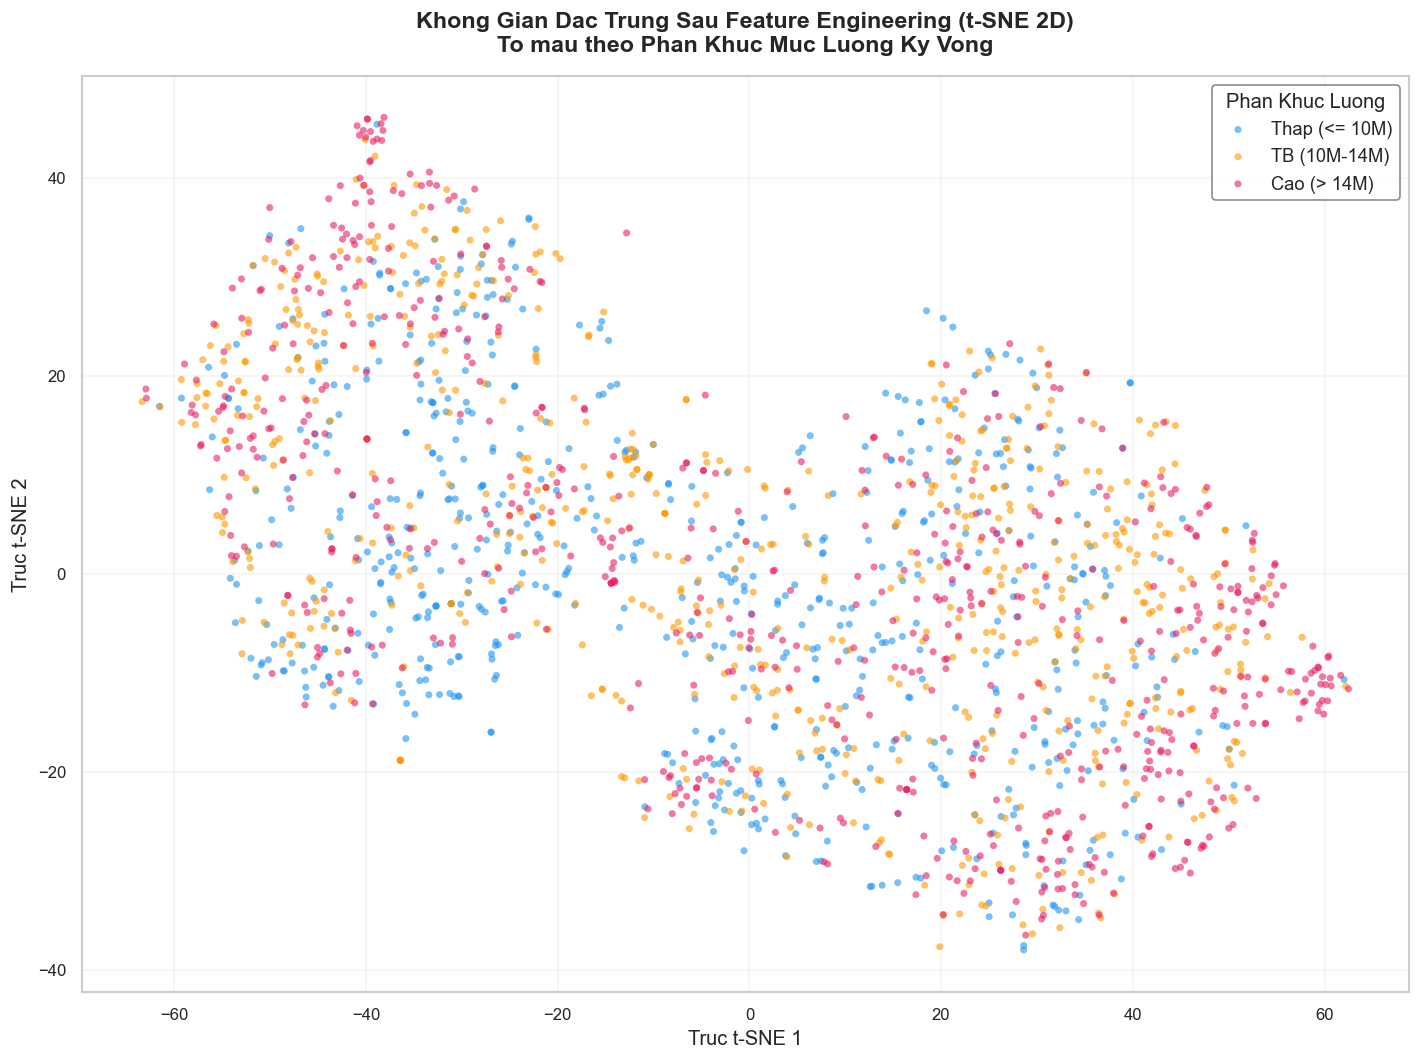

NHAN XET:
  - Neu 3 nhom mau tao ra cac cum (cluster) tach biet,
    Feature Engineering da tao ra dac trung voi kha nang phan tach tot.
  - Cac vung mau xen lan nhau la binh thuong (nhieu tu nhien).


In [ ]:
# Ve Scatter Plot 2D tu ket qua t-SNE
fig, ax = plt.subplots(figsize=(12, 9))

# Mapping mau sac cho tung phan khuc luong
category_colors = {
    label_low : '#2196F3',   # Xanh duong - Luong thap
    label_mid : '#FF9800',   # Cam       - Luong trung binh
    label_high: '#E91E63',   # Do/Hong   - Luong cao
}

for label, color in category_colors.items():
    mask = y_tsne_labels == label
    ax.scatter(
        X_2d[mask, 0], X_2d[mask, 1],
        c=color, label=label,
        alpha=0.6, s=18, edgecolors='none'
    )

ax.set_title(
    'Khong Gian Dac Trung Sau Feature Engineering (t-SNE 2D)\n'
    'To mau theo Phan Khuc Muc Luong Ky Vong',
    fontsize=14, fontweight='bold', pad=15
)
ax.set_xlabel('Truc t-SNE 1', fontsize=12)
ax.set_ylabel('Truc t-SNE 2', fontsize=12)
ax.legend(title='Phan Khuc Luong', fontsize=11, title_fontsize=12,
          framealpha=0.9, edgecolor='gray')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print('NHAN XET:')
print('  - Neu 3 nhom mau tao ra cac cum (cluster) tach biet,')
print('    Feature Engineering da tao ra dac trung voi kha nang phan tach tot.')
print('  - Cac vung mau xen lan nhau la binh thuong (nhieu tu nhien).')


---
## Kết Luận Tổng Thể

| Bước | Kỹ thuật | Kết quả |
|------|----------|--------|
| **EDA** | Histogram + KDE, Boxplot, Countplot | Phân bố lệch phải rõ rệt; Lương tăng theo kinh nghiệm và học vấn |
| **Distribution Shift** | Overlapping KDE, Class Distribution Comparison | Không có Target Shift; Train/Test đồng nhất phân phối |
| **Keyword Matching** | Regex Pattern Matching | Trích xuất 19 đặc trưng kỹ năng/ngoại ngữ ảnh hưởng lương |
| **Ordinal Encoding** | Ánh xạ thứ tự tùy chỉnh | 2 đặc trưng kinh nghiệm và học vấn giữ nguyên tính đơn điệu |
| **One-Hot Encoding** | pd.get_dummies | ~15-20 đặc trưng vị trí địa lý, hình thức, ngành nghề |
| **TF-IDF + TruncatedSVD** | NLP Vectorization + Dim Reduction | 195 đặc trưng ngữ nghĩa văn bản dày đặc (dense) |
| **t-SNE Visualization** | Giảm chiều 2D | Hình ảnh trực quan hóa khả năng phân tách đặc trưng |

**Tổng số đặc trưng đầu ra:** Xem output ở ô `3.4` ở trên.

**File đặc trưng đã lưu:** `../artifacts/features/engineered_features_train.csv`


---
## Bonus: Tạo tập đặc trưng cho tập Test

Người làm Modeling cần **cả 2 file**: `engineered_features_train.csv` và `engineered_features_test.csv`.

Cell dưới đây áp dụng **ĐÚNG CÁC BƯỚC FE ĐÃ FIT TRÊN TRAIN** (không fit lại) lên tập Test:
- `tfidf` đã fit trên Train → chỉ `transform()` Test  
- `svd` đã fit trên Train → chỉ `transform()` Test  
- Các mapping Ordinal/OHE cũng dùng y hệt Train

> ⚠️ **Nguyên tắc quan trọng:** KHÔNG được `fit_transform()` lại trên Test, chỉ được `transform()`.  
> Fit lại sẽ gây **Data Leakage** và làm mô hình đánh giá sai thực tế.

In [ ]:
# ============================================================
# BONUS: Áp dụng pipeline FE lên tập Test (KHÔNG fit lại)
# ============================================================
print("Dang load tap Test...")
df_test = pd.read_csv(TEST_PATH, nrows=int(SAMPLE_SIZE * 0.25) if SAMPLE_SIZE else None)
df_test['salary_avg'] = df_test['salary_expected_million_vnd'] * 1_000_000
# Chuẩn hóa cột kinh nghiệm
df_test['experience_level'] = df_test['experience_level'].apply(standardize_experience)
print(f"Test shape: {df_test.shape}")
# --- BUOC 1: Keyword Matching (dung cung KEYWORD_GROUPS voi Train, quet ca benefits) ---
print("\nBuoc 1: Keyword Matching (ky nang, ngoai ngu, phuc loi 0/1)...")
df_test = extract_keyword_features(df_test, KEYWORD_GROUPS)
# --- BUOC 2A: Ordinal Encoding (dung cung mapping voi Train) ---
print("Buoc 2: Ordinal Encoding...")
df_test['experience_encoded'] = df_test['experience_level'].map(EXPERIENCE_MAPPING).fillna(0).astype(float)
df_test['education_encoded']  = df_test['education_level'].map(EDUCATION_MAPPING).fillna(0).astype(int)
# --- BUOC 2B: Simplify Location + One-Hot Encoding ---
print("Buoc 3: Location simplify + One-Hot Encoding...")
df_test['location_simplified'] = df_test['location'].apply(simplify_location)
# Gop nhan hiem vao 'other' (dung cung nguong voi Train)
for col in nominal_cols_to_encode:
    valid_labels = set(df_fe[col].unique())  # Lay nhan da biet tu Train
    df_test[col] = df_test[col].where(df_test[col].isin(valid_labels), other='other')
    if col == 'location_simplified':
        df_test[col] = df_test['location_simplified']
# One-Hot Encoding cho Test (reindex theo cot cua Train de dam bao cung so cot)
df_ohe_test = pd.get_dummies(
    df_test[nominal_cols_to_encode],
    prefix=nominal_cols_to_encode,
    drop_first=True,
    dtype=int
)
# Quan trong: Align cot Test theo cot Train, dien 0 cho cot thieu
df_ohe_test = df_ohe_test.reindex(columns=df_ohe.columns, fill_value=0)
df_test = pd.concat([df_test, df_ohe_test], axis=1)
# --- BUOC 3: TF-IDF + SVD - AP DUNG REGEX PHAU THUAT, KHONG GHEP BENEFITS THO ---
print("Buoc 4: TF-IDF transform (khong fit lai, ap dung Regex phau thuat)...")
# Áp dụng cùng hàm Regex phẫu thuật cho tập Test (KHÔNG ghép benefits thô)
df_test['clean_title'] = df_test['job_title'].apply(clean_salary_leakage_surgical)
df_test['clean_jd']    = df_test['job_description'].apply(clean_salary_leakage_surgical)
df_test['clean_req']   = df_test['requirements'].apply(clean_salary_leakage_surgical)

df_test['full_text'] = (
    df_test['clean_title'] + ' ' +
    df_test['clean_jd']   + ' ' +
    df_test['clean_req']
)
tfidf_test_matrix = tfidf.transform(df_test['full_text'])   # .transform() chu khong .fit_transform()
text_reduced_test  = svd.transform(tfidf_test_matrix)       # .transform() chu khong .fit_transform()
df_text_svd_test = pd.DataFrame(text_reduced_test, columns=svd_col_names, index=df_test.index)
df_test = pd.concat([df_test, df_text_svd_test], axis=1)
# --- BUOC 4: Chon cac cot features giong het Train ---
X_test  = df_test[final_feature_cols].fillna(0).astype(float)
y_test  = df_test['salary_avg']
print(f"\nX_test shape : {X_test.shape}")
print(f"y_test shape : {y_test.shape}")
print(f"X_train shape: {X.shape}  (de doi chieu)")
print(f"\nSo features khop: {X_test.shape[1] == X.shape[1]}  <- phai la True!")
# --- BUOC 5: Luu ra file CSV ---
X_test_save = X_test.copy()
X_test_save['salary_avg'] = y_test.values
test_output_path = os.path.join(FEATURES_DIR, 'engineered_features_test.csv')
X_test_save.to_csv(test_output_path, index=False)
print(f"\nDa luu: {test_output_path}")
print(f"File size: {os.path.getsize(test_output_path)/1024:.1f} KB")


Dang load tap Test...
Test shape: (5000, 26)

Buoc 1: Keyword Matching (ky nang, ngoai ngu, phuc loi 0/1)...
Buoc 2: Ordinal Encoding...
Buoc 3: Location simplify + One-Hot Encoding...
Buoc 4: TF-IDF transform (khong fit lai, ap dung Regex phau thuat)...

X_test shape : (5000, 268)
y_test shape : (5000,)
X_train shape: (19863, 268)  (de doi chieu)

So features khop: True  <- phai la True!

Da luu: ../artifacts/features\engineered_features_test.csv
File size: 21495.0 KB


---
## Huong dan bàn giao cho nguoi lam Modeling

### Input chinh xac cho Modeling phase:

```python
import pandas as pd

# --- Load du lieu ---
train = pd.read_csv('artifacts/features/engineered_features_train.csv')
test  = pd.read_csv('artifacts/features/engineered_features_test.csv')

# --- Tach features va target ---
X_train = train.drop(columns=['salary_avg'])  # 269 features
y_train = train['salary_avg']                 # don vi: VND

X_test  = test.drop(columns=['salary_avg'])   # 269 features - cung so cot voi Train
y_test  = test['salary_avg']                  # don vi: VND

print(X_train.shape)  # (n_train, 269)
print(X_test.shape)   # (n_test,  269)
```

### Mo ta 269 features:

| Nhom | So cot | Mo ta |
|------|--------|-------|
| Keyword Skills | 15 | Co/khong co ky nang Java, Python, SQL, Docker... (0/1) |
| Keyword Language | 4 | Co/khong co ngoai ngu Anh, Nhat, Trung, Han (0/1) |
| Keyword Benefits | 6 | Co/khong co phuc loi: bao hiem, thuong, laptop, healthcare... (0/1) |
| Ordinal Encoded | 2 | Kinh nghiem (0-10), Hoc van (0-5) |
| One-Hot Location | 7 | Dia diem: HN, HCM, Da Nang, Binh Duong... |
| One-Hot Job Type | 5 | Hinh thuc: Toan TG, Remote, Thuc tap... |
| One-Hot Industry | 35 | Nganh nghe: Marketing, IT, Ke toan... |
| TF-IDF + SVD | 195 | Ngu nghia van ban ngu canh (dense, lien tuc) |

### Cac mo hinh phu hop:
- **XGBoost / LightGBM / CatBoost** (tot nhat cho du lieu dang nay)
- **Random Forest**
- **Ridge Regression** (baseline)
- **Neural Network (MLP)**

### Metric danh gia (bai toan Regression):
- **RMSE** (Root Mean Squared Error)
- **MAE** (Mean Absolute Error)  
- **R2 Score** (He so xac dinh)
